# Research Seminar: Data Analysis in Finance

**Paper:** Machine Learning vs. Economic Restrictions: Evidence from Stock Return Predictability (Avramov, Cheng and Metzker, 2023)

**Group members:** Chistiakova Maria, Meyzler Liya, Rudko Sofia, Samoilova Maria


## 1. Data

We use daily prices and volumes for 50 large U.S. stocks from Yahoo Finance (2003–2026). We create 16 technical features and predict monthly returns using only information available before each investment period.

The data is split into training, validation and test sets, with 2021–2025 used for testing. Our stock selection includes only surviving companies, so survivorship bias is a limitation.

In [1]:
from pathlib import Path
import hashlib, json, shutil, sys, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, LIME, LAVENDER = '#102D69', '#DCFF05', '#DFC7F2'
plt.rcParams.update({'axes.prop_cycle': plt.cycler(color=[NAVY, LIME, LAVENDER, '#7A7A7A']),
                     'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

ROOT = Path('/content/person1_run') if Path('/content').exists() else Path.cwd() / 'person1_run'
ROOT.mkdir(parents=True, exist_ok=True)
print('Output folder:', ROOT.name, '| pandas', pd.__version__, '| numpy', np.__version__)

Output folder: person1_run | pandas 2.2.3 | numpy 2.1.3


In [2]:
DATA = Path('/content/daily_prices.csv.gz') if Path('/content').exists() else Path.cwd() / 'daily_prices.csv.gz'
if not DATA.exists():
    raise FileNotFoundError('daily_prices.csv.gz not found. Put it next to the notebook or in /content in Colab.')

EXPECTED_SHA256 = '4bfa38f66e2fdf58abc720090b0a5a196eeb56330b46544f7de8d1c301b4264d'
assert hashlib.sha256(DATA.read_bytes()).hexdigest() == EXPECTED_SHA256, 'Dataset checksum mismatch'

source_path = ROOT / 'daily_prices.csv.gz'
if DATA.resolve() != source_path.resolve():
    shutil.copyfile(DATA, source_path)
print('Dataset found and checksum verified.')

Dataset found and checksum verified.


In [3]:
SUPPORT_ZIP_SHA256 = '5ceffb1a5104d88fcc73623e3a6b37175376fea23cd900505d9888d23f1fd087'
SUPPORT_FILES = ['data_pipeline.py', 'test_data.py', 'MODEL_HANDOFF.md', 'RESEARCH_PROTOCOL.md',
                 'processed/data_dictionary.csv']

support_zip = next((p for p in [Path('/content/group17_support_files.zip'),
                                Path.cwd() / 'group17_support_files.zip',
                                ROOT / 'group17_support_files.zip'] if p.exists()), None)
if support_zip is None:
    raise FileNotFoundError('group17_support_files.zip not found. Put it next to the notebook or in /content in Colab.')
assert hashlib.sha256(support_zip.read_bytes()).hexdigest() == SUPPORT_ZIP_SHA256, 'Support archive checksum mismatch'

with zipfile.ZipFile(support_zip) as archive:
    archive.extractall(ROOT)
missing = [name for name in SUPPORT_FILES if not (ROOT / name).exists()]
assert not missing, f'Missing support files: {missing}'
print('Support files extracted:', ', '.join(SUPPORT_FILES))

Support files extracted: data_pipeline.py, test_data.py, MODEL_HANDOFF.md, RESEARCH_PROTOCOL.md, processed/data_dictionary.csv


In [4]:
import importlib.util
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

pipeline = load_module('data_pipeline', ROOT / 'data_pipeline.py')
raw = pd.read_csv(ROOT / 'daily_prices.csv.gz', parse_dates=['date'])
print('Shape:', raw.shape)
print('Stocks:', raw.ticker.nunique())
print('Dates:', raw.date.min().date(), 'to', raw.date.max().date())
print(raw.head(3).to_string(index=False))

Shape: (290350, 8)
Stocks: 50
Dates: 2003-01-02 to 2026-01-30
ticker       date     open     high      low    close    volume  adj_close
  AAPL 2003-01-02 0.256429 0.266429 0.256250 0.264286 181428800   0.221332
  AAPL 2003-01-03 0.264286 0.266607 0.260536 0.266071 147453600   0.222826
  AAPL 2003-01-06 0.268393 0.274643 0.265714 0.266071 390532800   0.222826


In [5]:
clean, removed, duplicate_count = pipeline.clean_daily(raw)
print('Exact duplicates:', duplicate_count)
print('Invalid records:', len(removed))
print('Clean stock-days:', len(clean))

Exact duplicates: 0
Invalid records: 0
Clean stock-days: 290350


In [6]:
panel, excluded, daily_with_features = pipeline.build_monthly(clean)
print('Panel rows:', len(panel), '| predictors:', len(pipeline.FEATURES))
print('Excluded feature-incomplete stock-months:', len(excluded))
print('Allowed predictors:', pipeline.FEATURES)
example = panel.loc[(panel.ticker == 'AAPL') & (panel.holding_month == '2021-01'),
                    ['ticker','signal_date','holding_month','entry_date','exit_date','target_return']]
print(example.to_string(index=False))

Panel rows: 12600 | predictors: 16
Excluded feature-incomplete stock-months: 0
Allowed predictors: ['ret_21d', 'ret_63d', 'ret_126d', 'ret_252d', 'momentum_252_21d', 'volatility_21d', 'volatility_63d', 'volatility_126d', 'downside_63d', 'price_to_ma_21d', 'price_to_ma_63d', 'price_to_ma_252d', 'drawdown_252d', 'volume_ratio_21_126d', 'volume_change_21d', 'positive_days_63d']
ticker signal_date holding_month entry_date  exit_date  target_return
  AAPL  2020-12-31       2021-01 2021-01-04 2021-02-01       0.036551


In [7]:
summary = panel.groupby('split').agg(rows=('ticker','size'), stocks=('ticker','nunique'),
                                     first_month=('holding_month','min'), last_month=('holding_month','max'))
print(summary.loc[['train','validation','test','purge']].to_string())
print('Purged months:', sorted(panel.loc[panel.split.eq('purge'), 'holding_month'].unique()))

            rows  stocks first_month last_month
split                                          
train       7150      50     2005-01    2016-11
validation  2350      50     2017-01    2020-11
test        3000      50     2021-01    2025-12
purge        100      50     2016-12    2020-12
Purged months: ['2016-12', '2020-12']


In [8]:
panel, quality = pipeline.run(ROOT)
test_module = load_module('test_data', ROOT / 'test_data.py')
checks = test_module.run_tests(ROOT)
(ROOT / 'processed/test_results.json').write_text(json.dumps(checks, indent=2), encoding='utf-8')
assert all(checks.values())
print('ALL DATA CHECKS PASSED:', len(checks), '/', len(checks))
print('Feature missing values:', int(panel[pipeline.FEATURES].isna().sum().sum()))
print('Flagged extreme daily moves:', quality['extreme_daily_moves_flagged_not_deleted'])

ALL DATA CHECKS PASSED: 22 / 22
Feature missing values: 0
Flagged extreme daily moves: 39


In [9]:
features = json.loads((ROOT / 'processed/feature_columns.json').read_text())
train = pd.read_csv(ROOT / 'processed/train.csv')
validation = pd.read_csv(ROOT / 'processed/validation.csv')
test = pd.read_csv(ROOT / 'processed/test.csv')
X_train, y_train = train[features], train['target_return']
X_validation, y_validation = validation[features], validation['target_return']
X_test, y_test = test[features], test['target_return']
print('Train:', X_train.shape, '| validation:', X_validation.shape, '| test:', X_test.shape)

Train: (7150, 16) | validation: (2350, 16) | test: (3000, 16)


In [10]:
handoff_path = ROOT / 'person2_handoff.zip'
with zipfile.ZipFile(handoff_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in sorted((ROOT / 'processed').glob('*')):
        if path.is_file():
            archive.write(path, path.name)
    for name in ['MODEL_HANDOFF.md', 'RESEARCH_PROTOCOL.md']:
        archive.write(ROOT / name, name)
print('READY:', handoff_path.name)

READY: person2_handoff.zip


## 2. Models and predictions
We use Ridge and NN3 to predict next-month returns from 16 technical features. This is our adaptation of the paper using our own dataset. We select hyperparameters on validation using monthly rank IC, as our portfolios depend on stock rankings. During the test period, models are refitted each January using only available data. NN3 predictions are averaged across nine seeds.

In [11]:
import os, random
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

GLOBAL_SEED = 42
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

OUT = ROOT / 'part2_models'
OUT.mkdir(parents=True, exist_ok=True)

print('scikit-learn:', sklearn.__version__, '| global seed:', GLOBAL_SEED)

scikit-learn: 1.6.1 | global seed: 42


In [12]:
EXPECTED_FEATURES = [
    'ret_21d', 'ret_63d', 'ret_126d', 'ret_252d', 'momentum_252_21d',
    'volatility_21d', 'volatility_63d', 'volatility_126d', 'downside_63d',
    'price_to_ma_21d', 'price_to_ma_63d', 'price_to_ma_252d', 'drawdown_252d',
    'volume_ratio_21_126d', 'volume_change_21d', 'positive_days_63d']
FORBIDDEN = ['target_return', 'entry_adj_close', 'exit_adj_close', 'ticker',
             'signal_date', 'holding_month', 'entry_date', 'exit_date', 'split']
DATE_COLS = ['signal_date', 'entry_date', 'exit_date']

for df in (train, validation, test):
    for col in DATE_COLS:
        df[col] = pd.to_datetime(df[col])

checks = {}
checks['features: exactly the 16 agreed columns'] = features == EXPECTED_FEATURES
checks['features: no forbidden column in X'] = not set(features) & set(FORBIDDEN)
checks['shapes: 7150 / 2350 / 3000 rows'] = (len(train), len(validation), len(test)) == (7150, 2350, 3000)

expected_months = {'train': ('2005-01', '2016-11'), 'validation': ('2017-01', '2020-11'), 'test': ('2021-01', '2025-12')}
for name, df in [('train', train), ('validation', validation), ('test', test)]:
    X = df[features].to_numpy(dtype=float)
    checks[f'{name}: X and y are finite'] = np.isfinite(X).all() and np.isfinite(df['target_return']).all()
    checks[f'{name}: no duplicate (ticker, signal_date)'] = not df.duplicated(['ticker', 'signal_date']).any()
    per_month = df.groupby('holding_month')['ticker'].nunique()
    checks[f'{name}: 50 stocks in every month'] = per_month.eq(50).all() and df.groupby('holding_month').size().eq(50).all()
    checks[f'{name}: holding months {expected_months[name][0]}..{expected_months[name][1]}'] = (
        (df.holding_month.min(), df.holding_month.max()) == expected_months[name])
    checks[f'{name}: split label correct'] = df['split'].eq(name).all()
    checks[f'{name}: signal < entry < exit'] = ((df.signal_date < df.entry_date) & (df.entry_date < df.exit_date)).all()
    rebuilt = df['exit_adj_close'] / df['entry_adj_close'] - 1
    checks[f'{name}: target = exit/entry - 1 (no extra shift)'] = np.allclose(rebuilt, df['target_return'], atol=1e-9)

checks['no overlap: last train label known before first validation signal'] = train.exit_date.max() <= validation.signal_date.min()
checks['no overlap: last validation label known before first test signal'] = validation.exit_date.max() <= test.signal_date.min()

for name, ok in checks.items():
    print('PASS' if ok else 'FAIL', '|', name)
assert all(checks.values()), 'Handoff check failed - stop and inspect'
print(f'\nALL HANDOFF CHECKS PASSED: {sum(checks.values())} / {len(checks)}')
print('Months: train', train.holding_month.nunique(), '| validation', validation.holding_month.nunique(), '| test', test.holding_month.nunique())

PASS | features: exactly the 16 agreed columns
PASS | features: no forbidden column in X
PASS | shapes: 7150 / 2350 / 3000 rows
PASS | train: X and y are finite
PASS | train: no duplicate (ticker, signal_date)
PASS | train: 50 stocks in every month
PASS | train: holding months 2005-01..2016-11
PASS | train: split label correct
PASS | train: signal < entry < exit
PASS | train: target = exit/entry - 1 (no extra shift)
PASS | validation: X and y are finite
PASS | validation: no duplicate (ticker, signal_date)
PASS | validation: 50 stocks in every month
PASS | validation: holding months 2017-01..2020-11
PASS | validation: split label correct
PASS | validation: signal < entry < exit
PASS | validation: target = exit/entry - 1 (no extra shift)
PASS | test: X and y are finite
PASS | test: no duplicate (ticker, signal_date)
PASS | test: 50 stocks in every month
PASS | test: holding months 2021-01..2025-12
PASS | test: split label correct
PASS | test: signal < entry < exit
PASS | test: target = 

In [13]:
def monthly_rank_ic(months, y_true, y_pred):
    frame = pd.DataFrame({'month': np.asarray(months), 'y': np.asarray(y_true, float), 'p': np.asarray(y_pred, float)})
    ics = {}
    for month, g in frame.groupby('month'):
        if g['p'].nunique() < 2:
            ics[month] = 0.0
        else:
            ics[month] = g['p'].rank().corr(g['y'].rank())
    return pd.Series(ics, name='rank_ic')

def evaluate_forecasts(y_true, y_pred, months):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    assert y_true.shape == y_pred.shape and np.isfinite(y_pred).all()
    err = y_true - y_pred
    ic = monthly_rank_ic(months, y_true, y_pred)
    const_months = pd.Series(y_pred).groupby(np.asarray(months)).nunique().lt(2).sum()
    return {
        'n_obs': len(y_true),
        'n_months': len(ic),
        'MSE': np.mean(err ** 2),
        'RMSE': np.sqrt(np.mean(err ** 2)),
        'MAE': np.mean(np.abs(err)),
        'R2_oos': 1 - np.sum(err ** 2) / np.sum(y_true ** 2),
        'IC_mean': ic.mean(),
        'IC_std': ic.std(),
        'IC_tstat': ic.mean() / (ic.std() / np.sqrt(len(ic))) if ic.std() > 0 else np.nan,
        'IC_pos_share': (ic > 0).mean(),
        'const_months': int(const_months),
    }

_m = validation['holding_month']
_y = validation['target_return']
perfect = evaluate_forecasts(_y, _y, _m)
zero = evaluate_forecasts(_y, np.zeros(len(_y)), _m)
assert abs(perfect['R2_oos'] - 1) < 1e-12 and abs(perfect['IC_mean'] - 1) < 1e-12
assert abs(zero['R2_oos']) < 1e-12 and zero['IC_mean'] == 0 and zero['const_months'] == 47
rng = np.random.default_rng(0)
noise = evaluate_forecasts(_y, rng.normal(0, 0.01, len(_y)), _m)
print('Perfect forecast   -> R2_oos = %.3f, IC_mean = %.3f' % (perfect['R2_oos'], perfect['IC_mean']))
print('Zero forecast      -> R2_oos = %.3f, IC_mean = %.3f, constant months = %d' % (zero['R2_oos'], zero['IC_mean'], zero['const_months']))
print('Random noise       -> R2_oos = %.3f, IC_mean = %.3f' % (noise['R2_oos'], noise['IC_mean']))
print('Mean validation return: %.4f (%.2f%% per month)' % (_y.mean(), 100 * _y.mean()))

Perfect forecast   -> R2_oos = 1.000, IC_mean = 1.000
Zero forecast      -> R2_oos = 0.000, IC_mean = 0.000, constant months = 47
Random noise       -> R2_oos = -0.010, IC_mean = 0.019
Mean validation return: 0.0147 (1.47% per month)


In [14]:
def make_ridge(alpha):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha)),
    ])

demo = make_ridge(alpha=1.0).fit(X_train, y_train)
scaler_means = pd.Series(demo.named_steps['scaler'].mean_, index=features)
assert np.allclose(scaler_means, X_train.mean()), 'Scaler was not fitted on train only'
assert not np.allclose(scaler_means, pd.concat([X_train, X_validation, X_test]).mean())
Z_val = demo.named_steps['scaler'].transform(X_validation)
print('Scaler fitted on', int(demo.named_steps['scaler'].n_samples_seen_), 'train rows only.')
print('Standardized validation X, mean of each column (not exactly 0 - expected):')
print(pd.Series(Z_val.mean(axis=0), index=features).round(2).to_string())

Scaler fitted on 7150 train rows only.
Standardized validation X, mean of each column (not exactly 0 - expected):
ret_21d                -0.01
ret_63d                 0.05
ret_126d                0.03
ret_252d                0.05
momentum_252_21d        0.05
volatility_21d         -0.06
volatility_63d         -0.05
volatility_126d        -0.04
downside_63d           -0.01
price_to_ma_21d        -0.05
price_to_ma_63d         0.00
price_to_ma_252d        0.04
drawdown_252d           0.07
volume_ratio_21_126d    0.02
volume_change_21d      -0.01
positive_days_63d       0.36


In [15]:
RIDGE_ALPHAS = [0.01, 0.1, 1, 10, 100, 1_000, 10_000]

rows, ridge_val_preds = [], {}
for alpha in RIDGE_ALPHAS:
    model = make_ridge(alpha).fit(X_train, y_train)
    pred_val = model.predict(X_validation)
    ridge_val_preds[alpha] = pred_val
    res = evaluate_forecasts(y_validation, pred_val, validation['holding_month'])
    res['alpha'] = alpha
    res['pred_std'] = pred_val.std()
    rows.append(res)

ridge_grid = pd.DataFrame(rows).set_index('alpha')
ridge_grid.to_csv(OUT / 'ridge_validation_grid.csv')

best_alpha = ridge_grid.sort_values(['IC_mean', 'MSE'], ascending=[False, True]).index[0]
print(ridge_grid[['MSE', 'MAE', 'R2_oos', 'IC_mean', 'IC_std', 'IC_tstat', 'IC_pos_share', 'pred_std']].round(5).to_string())
print('\nSelected alpha (max validation IC_mean, tie-break MSE):', best_alpha)

              MSE      MAE   R2_oos  IC_mean   IC_std  IC_tstat  IC_pos_share  pred_std
alpha                                                                                  
0.01      0.00748  0.06265 -0.07766 -0.02835  0.20110  -0.96658       0.42553   0.02131
0.10      0.00748  0.06265 -0.07763 -0.02823  0.20109  -0.96244       0.42553   0.02130
1.00      0.00748  0.06264 -0.07733 -0.02796  0.20120  -0.95260       0.42553   0.02127
10.00     0.00746  0.06257 -0.07453 -0.02772  0.20167  -0.94223       0.42553   0.02096
100.00    0.00734  0.06207 -0.05644 -0.02728  0.20803  -0.89890       0.44681   0.01875
1000.00   0.00701  0.06085 -0.00910 -0.03327  0.21848  -1.04403       0.46809   0.01174
10000.00  0.00675  0.05996  0.02793 -0.03939  0.23708  -1.13893       0.44681   0.00506

Selected alpha (max validation IC_mean, tie-break MSE): 100.0


                                MSE      MAE   R2_oos  IC_mean  IC_pos_share
train (in-sample)           0.00675  0.05909  0.06504  0.06314       0.65035
validation (out-of-sample)  0.00734  0.06207 -0.05644 -0.02728       0.44681

Ridge coefficients (per 1 std of feature, return units):
volatility_126d         0.02647
downside_63d           -0.02239
volatility_21d         -0.01431
price_to_ma_63d        -0.01294
ret_21d                 0.01206
drawdown_252d          -0.01088
volume_ratio_21_126d    0.00796
price_to_ma_21d        -0.00768
volume_change_21d      -0.00761
ret_252d                0.00584
ret_126d               -0.00570
volatility_63d          0.00453
price_to_ma_252d        0.00446
positive_days_63d       0.00263
ret_63d                -0.00063
momentum_252_21d        0.00023


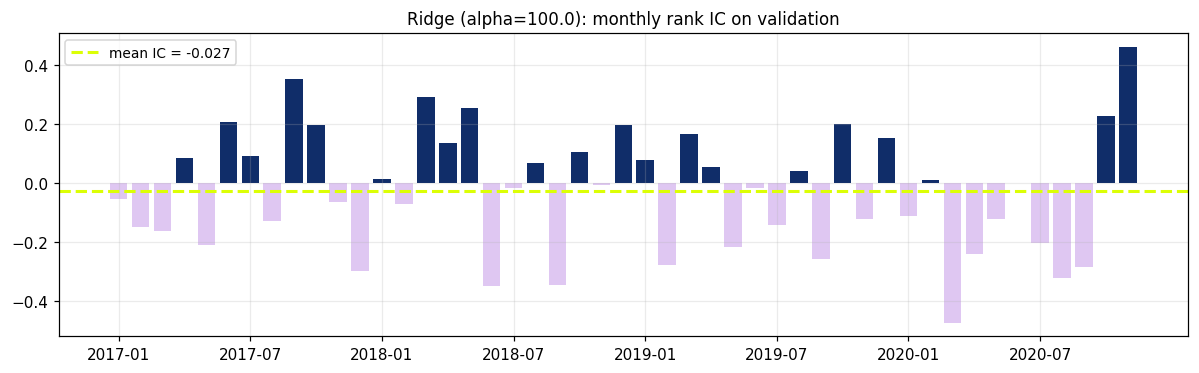


Saved: ridge_validation_predictions.csv (2350, 8)


In [16]:
ridge_final_val = make_ridge(best_alpha).fit(X_train, y_train)
pred_train = ridge_final_val.predict(X_train)
pred_val = ridge_final_val.predict(X_validation)

compare = pd.DataFrame({
    'train (in-sample)': evaluate_forecasts(y_train, pred_train, train['holding_month']),
    'validation (out-of-sample)': evaluate_forecasts(y_validation, pred_val, validation['holding_month']),
}).T[['MSE', 'MAE', 'R2_oos', 'IC_mean', 'IC_pos_share']]
print(compare.round(5).to_string())

coefs = pd.Series(ridge_final_val.named_steps['ridge'].coef_, index=features)
print('\nRidge coefficients (per 1 std of feature, return units):')
print(coefs.sort_values(key=np.abs, ascending=False).round(5).to_string())

ic_val = monthly_rank_ic(validation['holding_month'], y_validation, pred_val)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(ic_val.index, ic_val.values, color=np.where(ic_val.values > 0, NAVY, LAVENDER))
ax.axhline(ic_val.mean(), color=LIME, linewidth=2, linestyle='--', label=f'mean IC = {ic_val.mean():.3f}')
ax.set_title(f'Ridge (alpha={best_alpha}): monthly rank IC on validation')
ax.set_xticks(ic_val.index[::6])
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'ridge_validation_monthly_ic.png', dpi=150)
plt.show()

EXPORT_COLS = ['ticker', 'signal_date', 'holding_month', 'entry_date', 'exit_date',
               'model', 'predicted_return', 'target_return']
ridge_val_export = validation[['ticker', 'signal_date', 'holding_month', 'entry_date', 'exit_date', 'target_return']].copy()
ridge_val_export['model'] = 'ridge'
ridge_val_export['predicted_return'] = pred_val
ridge_val_export = ridge_val_export[EXPORT_COLS]
ridge_val_export.to_csv(OUT / 'ridge_validation_predictions.csv', index=False)
print('\nSaved:', (OUT / 'ridge_validation_predictions.csv').name, ridge_val_export.shape)

In [17]:
NN_FIT_END = '2014-10'
NN_PURGE_MONTH = '2014-11'
NN_TAIL_START, NN_TAIL_END = '2014-12', '2016-11'

nn_fit = train[train.holding_month <= NN_FIT_END].copy()
nn_purge = train[train.holding_month == NN_PURGE_MONTH].copy()
nn_tail = train[(train.holding_month >= NN_TAIL_START) & (train.holding_month <= NN_TAIL_END)].copy()

assert len(nn_fit) + len(nn_purge) + len(nn_tail) == len(train)
assert (len(nn_fit), len(nn_purge), len(nn_tail)) == (5900, 50, 1200)
assert nn_fit.exit_date.max() <= nn_tail.signal_date.min(), 'Leakage: a fit label ends after the first tail signal'

nn_scaler = StandardScaler().fit(nn_fit[features])
Xs_fit = nn_scaler.transform(nn_fit[features]).astype('float32')
Xs_tail = nn_scaler.transform(nn_tail[features]).astype('float32')
Xs_val = nn_scaler.transform(X_validation).astype('float32')
y_fit = nn_fit['target_return'].to_numpy('float32')
y_tail = nn_tail['target_return'].to_numpy('float32')
y_val = y_validation.to_numpy('float32')

print(pd.DataFrame({
    'rows': [len(nn_fit), len(nn_purge), len(nn_tail), len(validation)],
    'first_month': [nn_fit.holding_month.min(), NN_PURGE_MONTH, nn_tail.holding_month.min(), validation.holding_month.min()],
    'last_month': [nn_fit.holding_month.max(), NN_PURGE_MONTH, nn_tail.holding_month.max(), validation.holding_month.max()],
    'role': ['fit NN weights', 'dropped (label overlaps tail)', 'early stopping only', 'model selection only'],
}, index=['NN internal fit', 'NN internal purge', 'NN early-stopping tail', 'official validation']).to_string())
print('\nLast fit label known on', nn_fit.exit_date.max().date(), '| first tail signal', nn_tail.signal_date.min().date())
print('Scaler fitted on', int(nn_scaler.n_samples_seen_), 'rows (internal fit only)')

                        rows first_month last_month                           role
NN internal fit         5900     2005-01    2014-10                 fit NN weights
NN internal purge         50     2014-11    2014-11  dropped (label overlaps tail)
NN early-stopping tail  1200     2014-12    2016-11            early stopping only
official validation     2350     2017-01    2020-11           model selection only

Last fit label known on 2014-11-03 | first tail signal 2014-11-28
Scaler fitted on 5900 rows (internal fit only)


In [18]:
import tensorflow as tf
import keras
from keras import layers, regularizers

print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)

def build_nn3(l1_strength, learning_rate, n_inputs=16):
    reg = regularizers.l1(l1_strength)
    inputs = keras.Input(shape=(n_inputs,), name='features')
    x = inputs
    for i, width in enumerate([32, 16, 8], start=1):
        x = layers.Dense(width, kernel_regularizer=reg, name=f'hidden{i}_dense')(x)
        x = layers.BatchNormalization(name=f'hidden{i}_bn')(x)
        x = layers.Activation('relu', name=f'hidden{i}_relu')(x)
    outputs = layers.Dense(1, activation='linear', kernel_regularizer=reg, name='predicted_return')(x)
    model = keras.Model(inputs, outputs, name='NN3')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse', metrics=[keras.metrics.MeanSquaredError(name='mse')])
    return model

build_nn3(l1_strength=1e-4, learning_rate=1e-3).summary()

TensorFlow: 2.20.0 | Keras: 3.13.2


Model: "NN3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1_dense (Dense)           │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1_bn (BatchNormalization) │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1_relu (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2_dense (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2_bn (BatchNormalization) │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2_relu (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3_dense (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3_bn (BatchNormalization) │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3_relu (Activation)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_return (Dense)        │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,329 (5.19 KB)

 Non-trainable params: 112 (448.00 B)

In [19]:
BATCH_SIZE = 256
MAX_EPOCHS = 200
PATIENCE = 10

def train_nn3(l1_strength, learning_rate, seed):
    keras.utils.set_random_seed(seed)
    model = build_nn3(l1_strength, learning_rate)
    stopper = keras.callbacks.EarlyStopping(monitor='val_mse', mode='min', patience=PATIENCE,
                                            restore_best_weights=True)
    history = model.fit(Xs_fit, y_fit, validation_data=(Xs_tail, y_tail),
                        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, shuffle=True,
                        callbacks=[stopper], verbose=0)
    hist = pd.DataFrame(history.history)
    hist.index = hist.index + 1
    hist.index.name = 'epoch'
    best_epoch = int(hist['val_mse'].idxmin())
    return model, hist, best_epoch

debug_model, debug_hist, debug_best_epoch = train_nn3(l1_strength=1e-4, learning_rate=1e-3, seed=0)
debug_hist.to_csv(OUT / 'nn3_debug_history.csv')

pred_val_debug = debug_model.predict(Xs_val, verbose=0).ravel()
assert pred_val_debug.shape == (2350,) and np.isfinite(pred_val_debug).all()

print(f'Epochs run: {len(debug_hist)} | best epoch (min tail MSE): {debug_best_epoch}')
print(debug_hist.loc[[1, debug_best_epoch, len(debug_hist)], ['loss', 'mse', 'val_mse']].round(6).to_string())
print('\nPrediction std on validation: %.5f' % pred_val_debug.std())
debug_val = evaluate_forecasts(y_validation, pred_val_debug, validation['holding_month'])
print(pd.Series(debug_val)[['MSE', 'R2_oos', 'IC_mean', 'IC_tstat', 'IC_pos_share']].astype(float).round(5).to_string())

Epochs run: 85 | best epoch (min tail MSE): 75
           loss       mse   val_mse
epoch                              
1      0.219315  0.198105  0.010578
75     0.020631  0.006355  0.005072
85     0.019223  0.006246  0.005129

Prediction std on validation: 0.03970
MSE             0.00913
R2_oos         -0.31414
IC_mean        -0.02843
IC_tstat       -1.48320
IC_pos_share    0.40426


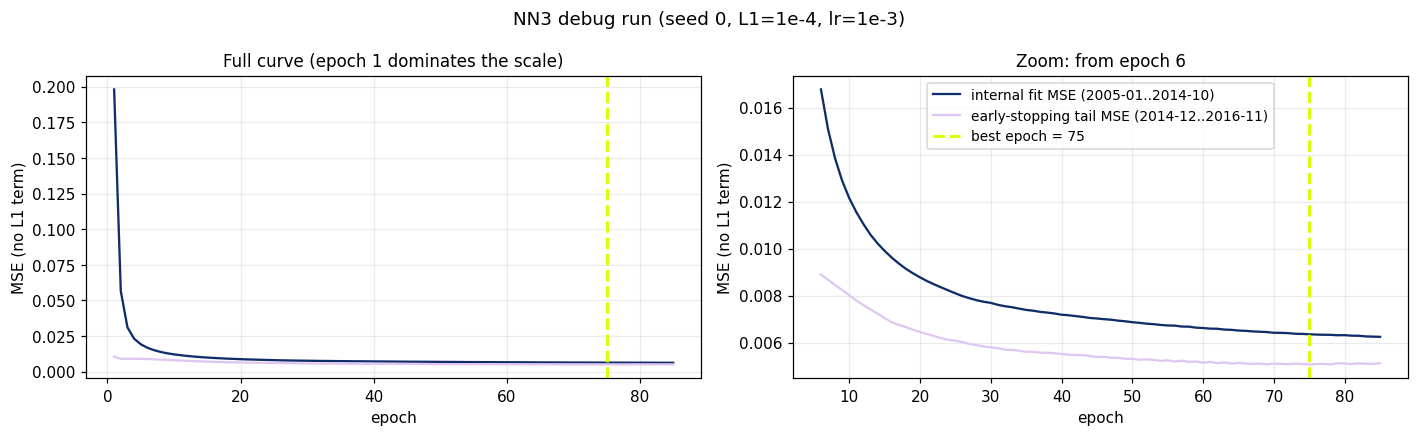

Epoch 1 fit MSE 0.1981 vs variance of y_fit 0.0076 -> initial outputs are far off the return scale
Best epoch 75: fit MSE 0.006355 | tail MSE 0.005072
Epochs 75->85 (after best): fit MSE -0.000109 | tail MSE +0.000057


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, start in zip(axes, [1, 6]):
    h = debug_hist.loc[start:]
    ax.plot(h.index, h['mse'], color=NAVY, label='internal fit MSE (2005-01..2014-10)')
    ax.plot(h.index, h['val_mse'], color=LAVENDER, label='early-stopping tail MSE (2014-12..2016-11)')
    ax.axvline(debug_best_epoch, color=LIME, linewidth=2, linestyle='--', label=f'best epoch = {debug_best_epoch}')
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE (no L1 term)')
axes[0].set_title('Full curve (epoch 1 dominates the scale)')
axes[1].set_title('Zoom: from epoch 6')
axes[1].legend()
plt.suptitle('NN3 debug run (seed 0, L1=1e-4, lr=1e-3)')
plt.tight_layout()
plt.savefig(OUT / 'nn3_debug_learning_curve.png', dpi=150)
plt.show()

b = debug_best_epoch
last = len(debug_hist)
print('Epoch 1 fit MSE %.4f vs variance of y_fit %.4f -> initial outputs are far off the return scale' % (
    debug_hist.loc[1, 'mse'], y_fit.var()))
print('Best epoch %d: fit MSE %.6f | tail MSE %.6f' % (b, debug_hist.loc[b, 'mse'], debug_hist.loc[b, 'val_mse']))
print('Epochs %d->%d (after best): fit MSE %+.6f | tail MSE %+.6f' % (
    b, last, debug_hist.loc[last, 'mse'] - debug_hist.loc[b, 'mse'], debug_hist.loc[last, 'val_mse'] - debug_hist.loc[b, 'val_mse']))

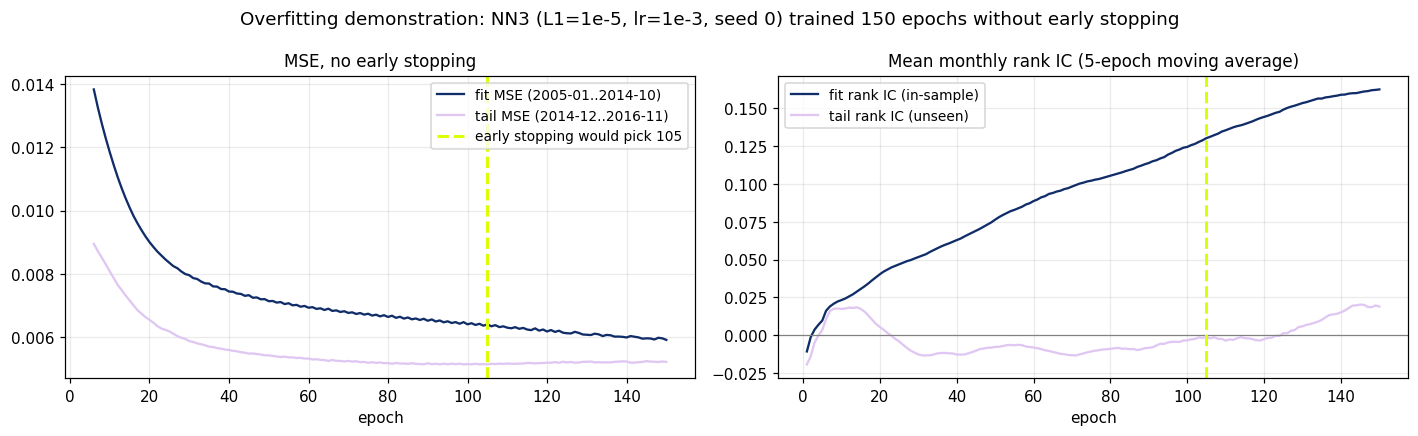

     fit_mse_eval  val_mse   fit_ic  tail_ic
1         0.02184  0.01057 -0.01080 -0.01940
10        0.01185  0.00807  0.02541  0.01631
105       0.00640  0.00513  0.13268 -0.00015
150       0.00591  0.00521  0.16345  0.01583

After epoch 105: fit MSE -0.000491, tail MSE +0.000079, fit IC +0.031, tail IC +0.016


In [21]:
class TailRankIC(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        p_fit = self.model.predict(Xs_fit, verbose=0).ravel()
        p_tail = self.model.predict(Xs_tail, verbose=0).ravel()
        logs['fit_mse_eval'] = float(np.mean((y_fit - p_fit) ** 2))
        logs['fit_ic'] = float(monthly_rank_ic(nn_fit['holding_month'], y_fit, p_fit).mean())
        logs['tail_ic'] = float(monthly_rank_ic(nn_tail['holding_month'], y_tail, p_tail).mean())

OVERFIT_EPOCHS = 150
keras.utils.set_random_seed(0)
demo_model = build_nn3(l1_strength=1e-5, learning_rate=1e-3)
demo_history = demo_model.fit(Xs_fit, y_fit, validation_data=(Xs_tail, y_tail), epochs=OVERFIT_EPOCHS,
                              batch_size=BATCH_SIZE, shuffle=True, callbacks=[TailRankIC()], verbose=0)
demo = pd.DataFrame(demo_history.history)
demo.index = demo.index + 1
demo.to_csv(OUT / 'nn3_overfit_demo_history.csv')
demo_best = int(demo['val_mse'].idxmin())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
h = demo.loc[6:]
axes[0].plot(h.index, h['fit_mse_eval'], color=NAVY, label='fit MSE (2005-01..2014-10)')
axes[0].plot(h.index, h['val_mse'], color=LAVENDER, label='tail MSE (2014-12..2016-11)')
axes[0].axvline(demo_best, color=LIME, linewidth=2, linestyle='--', label=f'early stopping would pick {demo_best}')
axes[0].set_title('MSE, no early stopping'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(demo.index, demo['fit_ic'].rolling(5, min_periods=1).mean(), color=NAVY, label='fit rank IC (in-sample)')
axes[1].plot(demo.index, demo['tail_ic'].rolling(5, min_periods=1).mean(), color=LAVENDER, label='tail rank IC (unseen)')
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].axvline(demo_best, color=LIME, linewidth=2, linestyle='--')
axes[1].set_title('Mean monthly rank IC (5-epoch moving average)'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.suptitle(f'Overfitting demonstration: NN3 (L1=1e-5, lr=1e-3, seed 0) trained {OVERFIT_EPOCHS} epochs without early stopping')
plt.tight_layout()
plt.savefig(OUT / 'nn3_overfitting_demo.png', dpi=150)
plt.show()

rows = [1, 10, demo_best, OVERFIT_EPOCHS]
print(demo.loc[rows, ['fit_mse_eval', 'val_mse', 'fit_ic', 'tail_ic']].round(5).to_string())
print('\nAfter epoch %d: fit MSE %+.6f, tail MSE %+.6f, fit IC %+.3f, tail IC %+.3f' % (
    demo_best,
    demo.loc[OVERFIT_EPOCHS, 'fit_mse_eval'] - demo.loc[demo_best, 'fit_mse_eval'],
    demo.loc[OVERFIT_EPOCHS, 'val_mse'] - demo.loc[demo_best, 'val_mse'],
    demo.loc[OVERFIT_EPOCHS, 'fit_ic'] - demo.loc[demo_best, 'fit_ic'],
    demo.loc[OVERFIT_EPOCHS, 'tail_ic'] - demo.loc[demo_best, 'tail_ic']))

In [22]:
import time, itertools
NN_L1_GRID = [1e-5, 1e-4, 1e-3]
NN_LR_GRID = [1e-3, 1e-2]
SELECTION_SEEDS = [0, 1, 2]

nn_rows, nn_run_log, nn_val_preds = [], [], {}
t0 = time.time()
for l1_strength, lr in itertools.product(NN_L1_GRID, NN_LR_GRID):
    seed_preds = []
    for seed in SELECTION_SEEDS:
        model, hist, best_epoch = train_nn3(l1_strength, lr, seed)
        p = model.predict(Xs_val, verbose=0).ravel()
        seed_preds.append(p)
        seed_res = evaluate_forecasts(y_validation, p, validation['holding_month'])
        nn_run_log.append({'l1': l1_strength, 'lr': lr, 'seed': seed, 'epochs_run': len(hist), 'best_epoch': best_epoch,
                           'fit_mse': hist.loc[best_epoch, 'mse'], 'tail_mse': hist.loc[best_epoch, 'val_mse'],
                           'val_IC_mean': seed_res['IC_mean'], 'val_MSE': seed_res['MSE'],
                           'val_pred_std': p.std(), 'const_months': seed_res['const_months']})
    ens = np.mean(seed_preds, axis=0)
    nn_val_preds[(l1_strength, lr)] = ens
    res = evaluate_forecasts(y_validation, ens, validation['holding_month'])
    res.update({'l1': l1_strength, 'lr': lr, 'pred_std': ens.std(),
                'mean_best_epoch': np.mean([r['best_epoch'] for r in nn_run_log[-3:]])})
    nn_rows.append(res)
    print(f'done: L1={l1_strength:g}, lr={lr:g} | IC_mean={res["IC_mean"]:.4f} | {time.time() - t0:.0f}s')

nn_run_log = pd.DataFrame(nn_run_log)
nn_grid = pd.DataFrame(nn_rows).set_index(['l1', 'lr'])
nn_run_log.to_csv(OUT / 'nn3_validation_run_log.csv', index=False)
nn_grid.to_csv(OUT / 'nn3_validation_grid.csv')

best_nn = nn_grid.sort_values(['IC_mean', 'MSE'], ascending=[False, True]).index[0]
BEST_L1, BEST_LR = best_nn
print('\nPer-seed runs:')
print(nn_run_log.round(5).to_string(index=False))
print('\n3-seed ensemble per configuration (official validation):')
print(nn_grid[['MSE', 'R2_oos', 'IC_mean', 'IC_std', 'IC_tstat', 'IC_pos_share', 'pred_std', 'const_months', 'mean_best_epoch']].round(5).to_string())
print(f'\nSelected NN3 config (max IC_mean, tie-break MSE): L1={BEST_L1:g}, lr={BEST_LR:g}')
collapsed = nn_run_log[nn_run_log.const_months > 0]
print('Seed runs with months of identical forecasts for all 50 stocks (collapsed network):')
print('none' if collapsed.empty else collapsed[['l1', 'lr', 'seed', 'best_epoch', 'val_pred_std', 'const_months']].round(5).to_string(index=False))

done: L1=1e-05, lr=0.001 | IC_mean=-0.0246 | 79s
done: L1=1e-05, lr=0.01 | IC_mean=-0.0404 | 112s
done: L1=0.0001, lr=0.001 | IC_mean=-0.0471 | 174s
done: L1=0.0001, lr=0.01 | IC_mean=-0.0141 | 209s
done: L1=0.001, lr=0.001 | IC_mean=-0.0226 | 250s
done: L1=0.001, lr=0.01 | IC_mean=0.0277 | 283s

Per-seed runs:
     l1    lr  seed  epochs_run  best_epoch  fit_mse  tail_mse  val_IC_mean  val_MSE  val_pred_std  const_months
0.00001 0.001     0         115         105  0.00617   0.00513     -0.02874  0.00957       0.04339             0
0.00001 0.001     1         123         113  0.00634   0.00505     -0.05173  0.00892       0.03803             0
0.00001 0.001     2          80          70  0.00635   0.00529      0.01043  0.00894       0.04013             0
0.00001 0.010     0          32          22  0.00641   0.00503     -0.02754  0.00859       0.03378             0
0.00001 0.010     1          40          30  0.00683   0.00480     -0.02888  0.00723       0.02307             0
0.00001 0

                                    MSE      MAE   R2_oos  IC_mean   IC_std  IC_tstat  IC_pos_share
Ridge (alpha=100)               0.00734  0.06207 -0.05644 -0.02728  0.20803  -0.89890       0.44681
NN3 3-seed (L1=0.001, lr=0.01)  0.00660  0.05940  0.04989  0.02767  0.21391   0.88682       0.51064

Monthly IC difference NN3 - Ridge: mean 0.0549, t-stat 1.35, NN3 better in 28 of 47 months
Average monthly rank correlation between Ridge and NN3 forecasts: 0.069


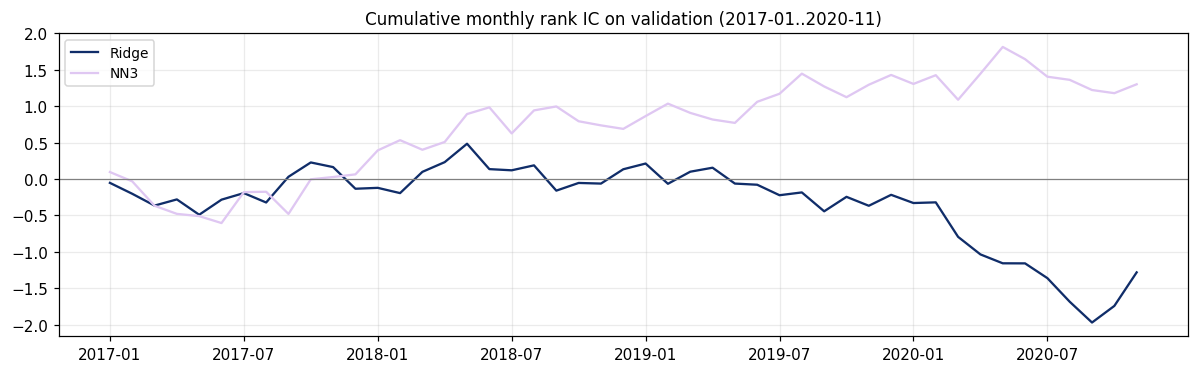

In [23]:
comparison = pd.DataFrame({
    f'Ridge (alpha={best_alpha:g})': evaluate_forecasts(y_validation, ridge_val_preds[best_alpha], validation['holding_month']),
    f'NN3 3-seed (L1={BEST_L1:g}, lr={BEST_LR:g})': evaluate_forecasts(y_validation, nn_val_preds[best_nn], validation['holding_month']),
}).T[['MSE', 'MAE', 'R2_oos', 'IC_mean', 'IC_std', 'IC_tstat', 'IC_pos_share']].astype(float)
comparison.to_csv(OUT / 'validation_ridge_vs_nn3.csv')
print(comparison.round(5).to_string())

ic_ridge = monthly_rank_ic(validation['holding_month'], y_validation, ridge_val_preds[best_alpha])
ic_nn = monthly_rank_ic(validation['holding_month'], y_validation, nn_val_preds[best_nn])
diff = ic_nn - ic_ridge
print('\nMonthly IC difference NN3 - Ridge: mean %.4f, t-stat %.2f, NN3 better in %d of %d months' % (
    diff.mean(), diff.mean() / (diff.std() / np.sqrt(len(diff))), (diff > 0).sum(), len(diff)))

same_month_corr = pd.DataFrame({'r': ridge_val_preds[best_alpha], 'n': nn_val_preds[best_nn],
                                'm': validation['holding_month'].values}).groupby('m').apply(
    lambda g: g['r'].rank().corr(g['n'].rank()), include_groups=False)
print('Average monthly rank correlation between Ridge and NN3 forecasts: %.3f' % same_month_corr.mean())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ic_ridge.index, ic_ridge.cumsum(), color=NAVY, label='Ridge')
ax.plot(ic_nn.index, ic_nn.cumsum(), color=LAVENDER, label='NN3')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(ic_ridge.index[::6])
ax.set_title('Cumulative monthly rank IC on validation (2017-01..2020-11)')
ax.legend(); plt.tight_layout()
plt.savefig(OUT / 'validation_cumulative_ic.png', dpi=150)
plt.show()

In [24]:
BEST_L1, BEST_LR = float(BEST_L1), float(BEST_LR)

fit_preds, tail_preds, val_preds_sel, alive = [], [], [], []
for seed in SELECTION_SEEDS:
    m, h, be = train_nn3(BEST_L1, BEST_LR, seed)
    pf, pt, pv = (m.predict(X, verbose=0).ravel() for X in (Xs_fit, Xs_tail, Xs_val))
    fit_preds.append(pf); tail_preds.append(pt); val_preds_sel.append(pv)
    alive.append(pv.std() > 1e-8)

ridge_sel = make_ridge(best_alpha).fit(X_train, y_train)
periods = {
    'NN fit 2005-01..2014-10 (in-sample)': (nn_fit, np.mean(fit_preds, axis=0), ridge_sel.predict(nn_fit[features])),
    'NN tail 2014-12..2016-11 (ES / Ridge in-sample)': (nn_tail, np.mean(tail_preds, axis=0), ridge_sel.predict(nn_tail[features])),
    'Validation 2017-01..2020-11 (out-of-sample)': (validation, np.mean(val_preds_sel, axis=0), ridge_sel.predict(X_validation)),
}
rows = []
for name, (df, p_nn, p_ridge) in periods.items():
    for model_name, p in [('NN3', p_nn), ('Ridge', p_ridge)]:
        r = evaluate_forecasts(df['target_return'], p, df['holding_month'])
        rows.append({'period': name, 'model': model_name, 'MSE': r['MSE'], 'R2_oos': r['R2_oos'],
                     'IC_mean': r['IC_mean'], 'IC_tstat': r['IC_tstat']})
overfit_table = pd.DataFrame(rows).set_index(['period', 'model'])
overfit_table.to_csv(OUT / 'overfitting_by_period.csv')
print(overfit_table.round(4).to_string())
print(f'\nSelected NN3 (L1={BEST_L1:g}, lr={BEST_LR:g}): {sum(alive)} of {len(alive)} seeds produce non-constant forecasts')
print('Validation IC of re-trained ensemble: %.4f (grid search value: %.4f)' % (
    evaluate_forecasts(y_validation, np.mean(val_preds_sel, axis=0), validation['holding_month'])['IC_mean'],
    nn_grid.loc[best_nn, 'IC_mean']))

def dispersion(pred, months):
    s = pd.Series(pred, index=np.asarray(months))
    within = s.groupby(level=0).std().mean()
    between = s.groupby(level=0).mean().std()
    return within, between
for name, p in [('Ridge', ridge_sel.predict(X_validation)), ('NN3', np.mean(val_preds_sel, axis=0))]:
    w, bt = dispersion(p, validation['holding_month'])
    print(f'{name}: std of forecasts across 50 stocks within a month = {w:.5f} | std of monthly average forecast = {bt:.5f}')

                                                          MSE  R2_oos  IC_mean  IC_tstat
period                                          model                                   
NN fit 2005-01..2014-10 (in-sample)             NN3    0.0076  0.0250   0.0394    1.7757
                                                Ridge  0.0072  0.0709   0.0652    3.7161
NN tail 2014-12..2016-11 (ES / Ridge in-sample) NN3    0.0046  0.0319   0.1093    2.7385
                                                Ridge  0.0046  0.0238   0.0600    1.4308
Validation 2017-01..2020-11 (out-of-sample)     NN3    0.0066  0.0499   0.0277    0.8868
                                                Ridge  0.0073 -0.0564  -0.0273   -0.8989

Selected NN3 (L1=0.001, lr=0.01): 3 of 3 seeds produce non-constant forecasts
Validation IC of re-trained ensemble: 0.0277 (grid search value: 0.0277)
Ridge: std of forecasts across 50 stocks within a month = 0.01244 | std of monthly average forecast = 0.01376
NN3: std of forecasts acro

In [25]:
import datetime
FINAL_SEEDS = list(range(9))
first_test_signal = test.signal_date.min()
frozen = {
    'frozen_at_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(timespec='seconds'),
    'test_metrics_computed_before_freeze': False,
    'features': features,
    'target': 'target_return (no shift, no clipping)',
    'selection_criterion': 'max mean monthly Spearman rank IC on validation 2017-01..2020-11, tie-break MSE',
    'ridge': {'alpha': float(best_alpha), 'grid': RIDGE_ALPHAS},
    'nn3': {'architecture': '16-32-16-8-1, Dense -> BatchNorm -> ReLU, linear output',
            'l1': float(BEST_L1), 'learning_rate': float(BEST_LR),
            'grid': {'l1': NN_L1_GRID, 'learning_rate': NN_LR_GRID},
            'batch_size': BATCH_SIZE, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
            'early_stopping_monitor': 'MSE on last 24 available holding months, 1-month purge before them',
            'final_seeds': FINAL_SEEDS,
            'collapsed_seeds_rule': 'kept in the ensemble average; a constant forecast does not change monthly ranks; count reported'},
    'refit': {'scheme': 'annual expanding window',
              'cutoffs': 'signal date of each January holding month 2021..2025',
              'training_rows': 'all panel rows with exit_date <= cutoff (includes earlier test months once their labels are known)',
              'scaler': 'refit on the training rows of each refit'},
    'validation_results': {'ridge_IC_mean': float(ridge_grid.loc[best_alpha, 'IC_mean']),
                           'nn3_IC_mean': float(nn_grid.loc[best_nn, 'IC_mean'])},
    'first_test_signal_date': str(first_test_signal.date()),
}
with open(OUT / 'frozen_choices.json', 'w') as f:
    json.dump(frozen, f, indent=2)
print(json.dumps(frozen, indent=2))

{
  "frozen_at_utc": "2026-09-21T12:32:21+00:00",
  "test_metrics_computed_before_freeze": false,
  "features": [
    "ret_21d",
    "ret_63d",
    "ret_126d",
    "ret_252d",
    "momentum_252_21d",
    "volatility_21d",
    "volatility_63d",
    "volatility_126d",
    "downside_63d",
    "price_to_ma_21d",
    "price_to_ma_63d",
    "price_to_ma_252d",
    "drawdown_252d",
    "volume_ratio_21_126d",
    "volume_change_21d",
    "positive_days_63d"
  ],
  "target": "target_return (no shift, no clipping)",
  "selection_criterion": "max mean monthly Spearman rank IC on validation 2017-01..2020-11, tie-break MSE",
  "ridge": {
    "alpha": 100.0,
    "grid": [
      0.01,
      0.1,
      1,
      10,
      100,
      1000,
      10000
    ]
  },
  "nn3": {
    "architecture": "16-32-16-8-1, Dense -> BatchNorm -> ReLU, linear output",
    "l1": 0.001,
    "learning_rate": 0.01,
    "grid": {
      "l1": [
        1e-05,
        0.0001,
        0.001
      ],
      "learning_rate": [
   

In [26]:
panel_all = pd.read_csv(ROOT / 'processed/panel_monthly.csv')
for col in DATE_COLS:
    panel_all[col] = pd.to_datetime(panel_all[col])
assert len(panel_all) == 12600 and not panel_all.duplicated(['ticker', 'signal_date']).any()

TEST_YEARS = [2021, 2022, 2023, 2024, 2025]
TAIL_MONTHS = 24

def refit_plan(year):
    cutoff = test.loc[test.holding_month == f'{year}-01', 'signal_date'].unique()
    assert len(cutoff) == 1
    cutoff = cutoff[0]
    available = panel_all[panel_all.exit_date <= cutoff]
    months = sorted(available.holding_month.unique())
    tail_months = months[-TAIL_MONTHS:]
    purge_month = months[-TAIL_MONTHS - 1]
    fit_months = months[:-TAIL_MONTHS - 1]
    fit = available[available.holding_month.isin(fit_months)]
    tail = available[available.holding_month.isin(tail_months)]
    predict_rows = test[test.holding_month.str.startswith(str(year))]
    assert available.exit_date.max() <= cutoff
    assert fit.exit_date.max() <= tail.signal_date.min()
    assert predict_rows.signal_date.min() >= cutoff
    return {'year': year, 'cutoff': cutoff, 'available': available, 'fit': fit, 'tail': tail,
            'purge_month': purge_month, 'predict': predict_rows}

plans = {y: refit_plan(y) for y in TEST_YEARS}
print(pd.DataFrame([{
    'test_year': y, 'cutoff (signal date)': p['cutoff'].date(),
    'train rows (Ridge)': len(p['available']), 'last label month': p['available'].holding_month.max(),
    'NN fit': f"{p['fit'].holding_month.min()}..{p['fit'].holding_month.max()}",
    'NN purge': p['purge_month'],
    'NN tail': f"{p['tail'].holding_month.min()}..{p['tail'].holding_month.max()}",
    'predict rows': len(p['predict'])} for y, p in plans.items()]).to_string(index=False))
assert sum(len(p['predict']) for p in plans.values()) == len(test)

 test_year cutoff (signal date)  train rows (Ridge) last label month           NN fit NN purge          NN tail  predict rows
      2021           2020-12-31                9550          2020-11 2005-01..2018-10  2018-11 2018-12..2020-11           600
      2022           2021-12-31               10150          2021-11 2005-01..2019-10  2019-11 2019-12..2021-11           600
      2023           2022-12-30               10750          2022-11 2005-01..2020-10  2020-11 2020-12..2022-11           600
      2024           2023-12-29               11350          2023-11 2005-01..2021-10  2021-11 2021-12..2023-11           600
      2025           2024-12-31               11950          2024-11 2005-01..2022-10  2022-11 2022-12..2024-11           600


In [27]:
ridge_test_parts = []
for y, p in plans.items():
    model = make_ridge(best_alpha).fit(p['available'][features], p['available']['target_return'])
    part = p['predict'][['ticker', 'signal_date', 'holding_month', 'entry_date', 'exit_date', 'target_return']].copy()
    part['predicted_return'] = model.predict(p['predict'][features])
    part['refit_cutoff'] = p['cutoff']
    ridge_test_parts.append(part)
ridge_test = pd.concat(ridge_test_parts).sort_values(['holding_month', 'ticker']).reset_index(drop=True)
ridge_test['model'] = 'ridge'
assert len(ridge_test) == 3000 and ridge_test.predicted_return.notna().all()
print('Ridge test predictions:', ridge_test.shape, '| refits:', ridge_test.refit_cutoff.nunique())
print(ridge_test.groupby(ridge_test.holding_month.str[:4])['predicted_return'].agg(['count', 'mean', 'std']).round(5).to_string())

Ridge test predictions: (3000, 9) | refits: 5
               count     mean      std
holding_month                         
2021             600  0.01468  0.00873
2022             600  0.01671  0.01120
2023             600  0.01395  0.00964
2024             600  0.00984  0.01005
2025             600  0.01370  0.01154


In [28]:
def train_nn3_on(fit_df, tail_df, seed):
    scaler = StandardScaler().fit(fit_df[features])
    Xf = scaler.transform(fit_df[features]).astype('float32')
    Xt = scaler.transform(tail_df[features]).astype('float32')
    keras.utils.set_random_seed(seed)
    model = build_nn3(BEST_L1, BEST_LR)
    stopper = keras.callbacks.EarlyStopping(monitor='val_mse', mode='min', patience=PATIENCE, restore_best_weights=True)
    hist = model.fit(Xf, fit_df['target_return'].to_numpy('float32'),
                     validation_data=(Xt, tail_df['target_return'].to_numpy('float32')),
                     epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, shuffle=True, callbacks=[stopper], verbose=0)
    best_epoch = int(np.argmin(hist.history['val_mse'])) + 1
    return model, scaler, best_epoch, len(hist.history['val_mse'])

# (a) validation predictions
t0 = time.time()
val_seed_preds = []
for seed in FINAL_SEEDS:
    model, scaler, be, ne = train_nn3_on(nn_fit, nn_tail, seed)
    val_seed_preds.append(model.predict(scaler.transform(X_validation).astype('float32'), verbose=0).ravel())
val_seed_preds = np.array(val_seed_preds)
nn3_val_alive = int((val_seed_preds.std(axis=1) > 1e-8).sum())
print(f'Validation ensemble: {nn3_val_alive} of {len(FINAL_SEEDS)} seeds non-constant | {time.time() - t0:.0f}s')

# (b) test predictions
nn_test_parts, nn_refit_log = [], []
for y, p in plans.items():
    seed_preds = []
    for seed in FINAL_SEEDS:
        model, scaler, be, ne = train_nn3_on(p['fit'], p['tail'], seed)
        pr = model.predict(scaler.transform(p['predict'][features]).astype('float32'), verbose=0).ravel()
        seed_preds.append(pr)
        nn_refit_log.append({'test_year': y, 'seed': seed, 'fit_rows': len(p['fit']), 'tail_rows': len(p['tail']),
                             'best_epoch': be, 'epochs_run': ne, 'pred_std': pr.std(), 'collapsed': pr.std() <= 1e-8})
    part = p['predict'][['ticker', 'signal_date', 'holding_month', 'entry_date', 'exit_date', 'target_return']].copy()
    part['predicted_return'] = np.mean(seed_preds, axis=0)
    part['refit_cutoff'] = p['cutoff']
    nn_test_parts.append(part)
    print(f'{y}: 9 seeds done, collapsed = {sum(r["collapsed"] for r in nn_refit_log[-9:])} | {time.time() - t0:.0f}s')

nn3_test = pd.concat(nn_test_parts).sort_values(['holding_month', 'ticker']).reset_index(drop=True)
nn3_test['model'] = 'nn3'
nn_refit_log = pd.DataFrame(nn_refit_log)
nn_refit_log.to_csv(OUT / 'nn3_test_refit_log.csv', index=False)
assert len(nn3_test) == 3000 and nn3_test.predicted_return.notna().all()
print(nn_refit_log.groupby('test_year').agg(fit_rows=('fit_rows', 'first'), mean_best_epoch=('best_epoch', 'mean'),
                                            collapsed_seeds=('collapsed', 'sum')).to_string())

Validation ensemble: 9 of 9 seeds non-constant | 113s
2021: 9 seeds done, collapsed = 0 | 198s
2022: 9 seeds done, collapsed = 0 | 288s
2023: 9 seeds done, collapsed = 0 | 388s
2024: 9 seeds done, collapsed = 0 | 477s
2025: 9 seeds done, collapsed = 0 | 587s
           fit_rows  mean_best_epoch  collapsed_seeds
test_year                                            
2021           8300        12.111111                0
2022           8900        13.000000                0
2023           9500        16.000000                0
2024          10100        11.888889                0
2025          10700        19.888889                0


TEST 2021-01..2025-12 (computed once, after freeze)
        n_obs  n_months      MSE      MAE   R2_oos  IC_mean   IC_std  IC_tstat  IC_pos_share  const_months
Ridge  3000.0      60.0  0.00667  0.06244  0.03539  0.02530  0.20221   0.96917       0.51667           0.0
NN3    3000.0      60.0  0.00682  0.06284  0.01374 -0.01056  0.19327  -0.42333       0.48333           0.0

NN3 - Ridge monthly IC: mean -0.0359, t-stat -1.40, NN3 better in 25 of 60 months

Mean IC by test year:
      Ridge IC  NN3 IC
2021    0.0415  0.0164
2022    0.0523 -0.0765
2023    0.0571  0.1026
2024   -0.0377 -0.1069
2025    0.0133  0.0115

        validation IC_mean  test IC_mean  test IC_tstat  test R2_oos
Ridge             -0.0273        0.0253         0.9692       0.0354
NN3                0.0277       -0.0106        -0.4233       0.0137


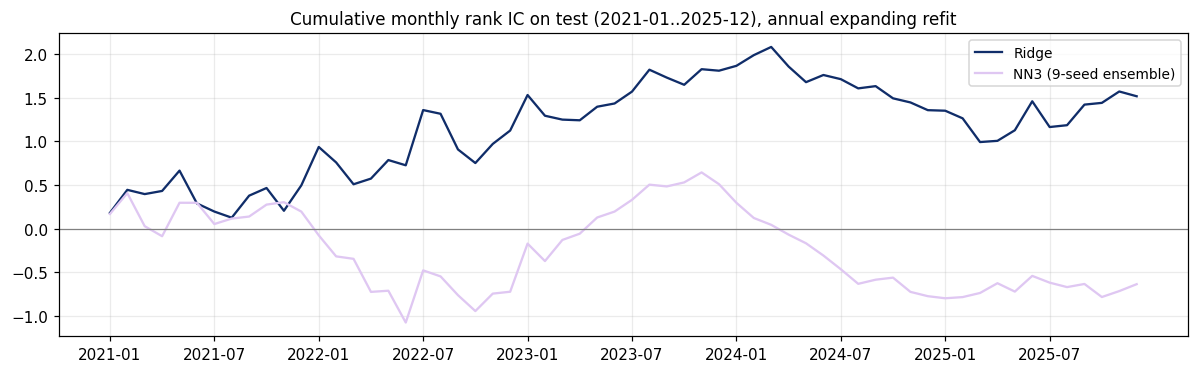

In [29]:
test_eval = {}
for name, df in [('Ridge', ridge_test), ('NN3', nn3_test)]:
    test_eval[name] = evaluate_forecasts(df['target_return'], df['predicted_return'], df['holding_month'])
test_table = pd.DataFrame(test_eval).T[['n_obs', 'n_months', 'MSE', 'MAE', 'R2_oos', 'IC_mean', 'IC_std', 'IC_tstat', 'IC_pos_share', 'const_months']]
test_table.to_csv(OUT / 'test_metrics.csv')
print('TEST 2021-01..2025-12 (computed once, after freeze)')
print(test_table.astype(float).round(5).to_string())

ic_r = monthly_rank_ic(ridge_test.holding_month, ridge_test.target_return, ridge_test.predicted_return)
ic_n = monthly_rank_ic(nn3_test.holding_month, nn3_test.target_return, nn3_test.predicted_return)
d = ic_n - ic_r
print('\nNN3 - Ridge monthly IC: mean %.4f, t-stat %.2f, NN3 better in %d of %d months' % (
    d.mean(), d.mean() / (d.std() / np.sqrt(len(d))), (d > 0).sum(), len(d)))

by_year = pd.DataFrame({'Ridge IC': ic_r.groupby(ic_r.index.str[:4]).mean(),
                        'NN3 IC': ic_n.groupby(ic_n.index.str[:4]).mean()})
print('\nMean IC by test year:')
print(by_year.round(4).to_string())

summary = pd.DataFrame({
    'validation IC_mean': [ridge_grid.loc[best_alpha, 'IC_mean'], nn_grid.loc[best_nn, 'IC_mean']],
    'test IC_mean': [test_eval['Ridge']['IC_mean'], test_eval['NN3']['IC_mean']],
    'test IC_tstat': [test_eval['Ridge']['IC_tstat'], test_eval['NN3']['IC_tstat']],
    'test R2_oos': [test_eval['Ridge']['R2_oos'], test_eval['NN3']['R2_oos']]}, index=['Ridge', 'NN3'])
summary.to_csv(OUT / 'validation_vs_test_summary.csv')
print('\n', summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ic_r.index, ic_r.cumsum(), color=NAVY, label='Ridge')
ax.plot(ic_n.index, ic_n.cumsum(), color=LAVENDER, label='NN3 (9-seed ensemble)')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(ic_r.index[::6])
ax.set_title('Cumulative monthly rank IC on test (2021-01..2025-12), annual expanding refit')
ax.legend(); plt.tight_layout()
plt.savefig(OUT / 'test_cumulative_ic.png', dpi=150)
plt.show()

with open(OUT / 'test_run_log.json', 'w') as f:
    json.dump({'test_evaluated_at_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(timespec='seconds'),
               'frozen_choices_file': 'frozen_choices.json', 'evaluated_once': True}, f, indent=2)

### Correction note: two NN3 runs (added after the research audit)

The NN3 numbers printed in cells 25–32 above, and the cumulative-IC figures produced in cells 26 and 32, come from a **re-run** of Part 2 (frozen at 2026-09-20). Parts 3 and 4 do **not** use this re-run. Cell 37 accepts only the frozen handoff `person3_person4_predictions.zip` (frozen at 2026-09-18, SHA-256 checked) and rejects re-generated NN3 forecasts.

The two runs use identical code, data, hyperparameters (L1 = 0.001, lr = 0.01) and seeds, but TensorFlow training is not fully deterministic, so the NN3 results differ:

| NN3 | Validation IC | Test IC | Test IC t-stat | Test R²_oos |
|---|---|---|---|---|
| Re-run (printed above, 2026-09-20) | 0.028 (3 seeds) | −0.011 | −0.42 | 0.014 |
| Frozen forecasts used in Parts 3–4 (2026-09-18) | 0.005 (3-seed selection); 0.004 (9-seed ensemble) | **0.018** | **0.62** | **0.024** |

Ridge is deterministic and identical in both runs (validation IC −0.027, test IC 0.025, t = 0.97, R²_oos = 0.035).

**Reporting rule:** all final results (the table in the next cell, the presentation and the scripts) use the frozen forecasts, because they are the forecasts that were traded. The re-run outputs are kept above, unchanged, for transparency. Consequences: there is no NN3 validation-to-test reversal in the traded forecasts; both models have weak, statistically insignificant ranking ability; and NN3 is unstable across runs (its test IC changed sign). The corrected cumulative-IC chart is produced after the frozen forecasts are loaded (new cell after cell 38).


In [30]:
nn3_val_export = validation[['ticker', 'signal_date', 'holding_month', 'entry_date', 'exit_date', 'target_return']].copy()
nn3_val_export['model'] = 'nn3'
nn3_val_export['predicted_return'] = val_seed_preds.mean(axis=0)

ridge_val_out = ridge_val_export.copy()
pred_validation = pd.concat([ridge_val_out, nn3_val_export[EXPORT_COLS]], ignore_index=True)
pred_test = pd.concat([ridge_test[EXPORT_COLS], nn3_test[EXPORT_COLS]], ignore_index=True)

for df in (pred_validation, pred_test):
    for col in DATE_COLS:
        df[col] = pd.to_datetime(df[col]).dt.strftime('%Y-%m-%d')
    df.sort_values(['model', 'holding_month', 'ticker'], inplace=True)
    df.reset_index(drop=True, inplace=True)

pred_validation.to_csv(OUT / 'predictions_validation.csv', index=False)
pred_test.to_csv(OUT / 'predictions_test.csv', index=False)
print('predictions_validation.csv:', pred_validation.shape, '| models:', sorted(pred_validation.model.unique()))
print('predictions_test.csv:      ', pred_test.shape, '| models:', sorted(pred_test.model.unique()))
print(pred_test.head(3).to_string(index=False))

predictions_validation.csv: (4700, 8) | models: ['nn3', 'ridge']
predictions_test.csv:       (6000, 8) | models: ['nn3', 'ridge']
ticker signal_date holding_month entry_date  exit_date model  predicted_return  target_return
  AAPL  2020-12-31       2021-01 2021-01-04 2021-02-01   nn3          0.011714       0.036551
   ABT  2020-12-31       2021-01 2021-01-04 2021-02-01   nn3          0.006881       0.127611
  ADBE  2020-12-31       2021-01 2021-01-04 2021-02-01   nn3          0.008770      -0.031607


In [31]:
def check_predictions(df, split_df, name):
    c = {}
    c[f'{name}: exact columns in agreed order'] = list(df.columns) == EXPORT_COLS
    c[f'{name}: models are ridge and nn3'] = set(df.model) == {'ridge', 'nn3'}
    c[f'{name}: no NaN / inf predictions'] = np.isfinite(df.predicted_return).all()
    c[f'{name}: no duplicate (model, ticker, signal_date)'] = not df.duplicated(['model', 'ticker', 'signal_date']).any()
    per = df.groupby(['model', 'holding_month'])['ticker'].nunique()
    c[f'{name}: exactly 50 stocks per model-month'] = per.eq(50).all() and df.groupby(['model', 'holding_month']).size().eq(50).all()
    months = sorted(split_df.holding_month.unique())
    c[f'{name}: all {len(months)} months present for both models'] = all(
        sorted(df.loc[df.model == m, 'holding_month'].unique()) == months for m in ['ridge', 'nn3'])
    key = ['ticker', 'signal_date']
    ref = split_df[key + ['holding_month', 'entry_date', 'exit_date', 'target_return']].copy()
    ref['signal_date'] = pd.to_datetime(ref['signal_date']).dt.strftime('%Y-%m-%d')
    for m in ['ridge', 'nn3']:
        merged = df[df.model == m].merge(ref, on=key, suffixes=('', '_ref'), validate='one_to_one')
        c[f'{name}/{m}: every row matches Part 1 (keys, dates, target)'] = (
            len(merged) == len(split_df)
            and (merged.holding_month == merged.holding_month_ref).all()
            and (merged.entry_date == pd.to_datetime(merged.entry_date_ref).dt.strftime('%Y-%m-%d')).all()
            and (merged.exit_date == pd.to_datetime(merged.exit_date_ref).dt.strftime('%Y-%m-%d')).all()
            and np.allclose(merged.target_return, merged.target_return_ref, atol=0))
        within_std = df[df.model == m].groupby('holding_month').predicted_return.std()
        c[f'{name}/{m}: forecasts differ across stocks in every month'] = (within_std > 0).all()
    c[f'{name}: ridge and nn3 forecasts are not identical'] = not np.allclose(
        df[df.model == 'ridge'].predicted_return.values, df[df.model == 'nn3'].predicted_return.values)
    return c

reloaded_val = pd.read_csv(OUT / 'predictions_validation.csv')
reloaded_test = pd.read_csv(OUT / 'predictions_test.csv')
checks2 = {}
checks2.update(check_predictions(reloaded_val, validation, 'validation'))
checks2.update(check_predictions(reloaded_test, test, 'test'))
checks2['test: refit cutoffs never after the forecast signal date'] = all(
    (df['refit_cutoff'] <= df['signal_date']).all() for df in (ridge_test, nn3_test))
checks2['test: every training label known at its cutoff'] = all(
    p['available'].exit_date.max() <= p['cutoff'] for p in plans.values())

for k, ok in checks2.items():
    print('PASS' if ok else 'FAIL', '|', k)
assert all(checks2.values()), 'Prediction export check failed'
print(f'\nALL PREDICTION CHECKS PASSED: {sum(checks2.values())} / {len(checks2)}')
(OUT / 'prediction_checks.json').write_text(json.dumps({k: bool(v) for k, v in checks2.items()}, indent=2))

handoff = ROOT / 'person3_person4_predictions.zip'
with zipfile.ZipFile(handoff, 'w', zipfile.ZIP_DEFLATED) as z:
    for fname in ['predictions_validation.csv', 'predictions_test.csv', 'frozen_choices.json',
                  'test_metrics.csv', 'prediction_checks.json', 'nn3_test_refit_log.csv']:
        z.write(OUT / fname, fname)
print('READY:', handoff)

PASS | validation: exact columns in agreed order
PASS | validation: models are ridge and nn3
PASS | validation: no NaN / inf predictions
PASS | validation: no duplicate (model, ticker, signal_date)
PASS | validation: exactly 50 stocks per model-month
PASS | validation: all 47 months present for both models
PASS | validation/ridge: every row matches Part 1 (keys, dates, target)
PASS | validation/ridge: forecasts differ across stocks in every month
PASS | validation/nn3: every row matches Part 1 (keys, dates, target)
PASS | validation/nn3: forecasts differ across stocks in every month
PASS | validation: ridge and nn3 forecasts are not identical
PASS | test: exact columns in agreed order
PASS | test: models are ridge and nn3
PASS | test: no NaN / inf predictions
PASS | test: no duplicate (model, ticker, signal_date)
PASS | test: exactly 50 stocks per model-month
PASS | test: all 60 months present for both models
PASS | test/ridge: every row matches Part 1 (keys, dates, target)
PASS | test

### Part 2 results (frozen forecasts used in Parts 3–4)

| | Validation IC | Test IC | Test IC t-stat | Test R²_oos |
|---|---|---|---|---|
| Ridge (alpha = 100) | −0.027 | 0.025 | 0.97 | 0.035 |
| NN3 (L1 = 1e-3, lr = 1e-2) | 0.005 | 0.018 | 0.62 | 0.024 |

Neither model ranks stocks significantly better than chance, and NN3 does not beat Ridge. The forecasts are frozen and exported to `person3_person4_predictions.zip`, which Parts 3 and 4 use.

## 3. Portfolio construction, turnover and trading costs
We build monthly long-only portfolios using the five stocks with the highest predicted returns. Each stock has equal weight. We compare the strategies with an equal-weighted portfolio of all 50 stocks.

We measure turnover and test trading costs of 0, 10, 25 and 50 bps per traded dollar, including trades in stocks that remain in the portfolio.

In [32]:
from pathlib import Path
import hashlib, io, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'ROOT' not in globals():
    ROOT = Path('/content/person1_run') if Path('/content').exists() else Path.cwd() / 'person1_run'
if 'NAVY' not in globals():
    NAVY, LIME, LAVENDER = '#102D69', '#DCFF05', '#DFC7F2'
    plt.rcParams.update({'axes.prop_cycle': plt.cycler(color=[NAVY, LIME, LAVENDER, '#7A7A7A']),
                         'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                         'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})
P3_OUT = ROOT / 'part3_portfolio'
P3_OUT.mkdir(parents=True, exist_ok=True)

FROZEN_SHA256 = {
    'predictions_validation.csv': '8c0d2871bf20e2eaf16ed37b645be95c5816d405cd32395155c9a81ebdb5c744',
    'predictions_test.csv':       '25a6628700919759d622f5e43b571fabe50748e0c8536fda4a2638946593f2a5',
}
HANDOFF_CANDIDATES = [Path('/content/person3_person4_predictions.zip'),
                      Path.cwd() / 'person3_person4_predictions.zip',
                      ROOT / 'person3_person4_predictions.zip']

def read_handoff(path):
    with zipfile.ZipFile(path) as z:
        raw = {name: z.read(name) for name in ['predictions_validation.csv', 'predictions_test.csv', 'frozen_choices.json']}
    hashes = {name: hashlib.sha256(raw[name]).hexdigest() for name in FROZEN_SHA256}
    return raw, hashes

HANDOFF, raw_files = None, None
for cand in HANDOFF_CANDIDATES:
    if cand.exists():
        raw_files, hashes = read_handoff(cand)
        if hashes == FROZEN_SHA256:
            HANDOFF = cand
            break
        print(f'Skipped {cand}: prediction files differ from the frozen handoff (probably a re-run of Part 2).')
if HANDOFF is None:
    raise FileNotFoundError('Frozen person3_person4_predictions.zip not found. Upload the file delivered by Person 2 '
                            'next to this notebook (or to /content in Colab). Do not use re-generated NN3 forecasts.')

frozen_choices = json.loads(raw_files['frozen_choices.json'])
P3_DATE_COLS = ['signal_date', 'entry_date', 'exit_date']
preds = {}
for split, fname in [('validation', 'predictions_validation.csv'), ('test', 'predictions_test.csv')]:
    df = pd.read_csv(io.BytesIO(raw_files[fname]))
    for col in P3_DATE_COLS:
        df[col] = pd.to_datetime(df[col])
    df['holding_month'] = df['holding_month'].astype(str)
    df['ticker'] = df['ticker'].astype(str)
    df['model'] = df['model'].astype(str)
    df['split'] = split
    preds[split] = df

print('Frozen handoff:', HANDOFF.name, '| SHA-256 verified')
print('Frozen Part 2 choices: Ridge alpha =', frozen_choices['ridge']['alpha'],
      '| NN3 L1 =', frozen_choices['nn3']['l1'], ', lr =', frozen_choices['nn3']['learning_rate'])
for split, df in preds.items():
    print(f'{split:>10}: {df.shape[0]:>5} rows | models {sorted(df.model.unique())} | '
          f'holding months {df.holding_month.min()}..{df.holding_month.max()} ({df.holding_month.nunique()})')

Frozen handoff: person3_person4_predictions.zip | SHA-256 verified
Frozen Part 2 choices: Ridge alpha = 100.0 | NN3 L1 = 0.001 , lr = 0.01
validation:  4700 rows | models ['nn3', 'ridge'] | holding months 2017-01..2020-11 (47)
      test:  6000 rows | models ['nn3', 'ridge'] | holding months 2021-01..2025-12 (60)


In [33]:
P3_COLS = ['ticker', 'signal_date', 'holding_month', 'entry_date', 'exit_date', 'model', 'predicted_return', 'target_return']
p3_checks = {}
for split, df in preds.items():
    p3_checks[f'{split}: agreed columns'] = list(df.columns[:8]) == P3_COLS
    p3_checks[f'{split}: finite forecasts and targets'] = bool(np.isfinite(df[['predicted_return', 'target_return']]).all().all())
    p3_checks[f'{split}: no duplicate (model, ticker, signal_date)'] = not df.duplicated(['model', 'ticker', 'signal_date']).any()
    p3_checks[f'{split}: 50 stocks in every model-month'] = df.groupby(['model', 'holding_month']).ticker.nunique().eq(50).all()
    dates = df.groupby('holding_month')[P3_DATE_COLS].nunique()
    p3_checks[f'{split}: one signal/entry/exit date per month'] = dates.eq(1).all().all()
    cal = df.groupby('holding_month')[P3_DATE_COLS].first().sort_index()
    p3_checks[f'{split}: signal < entry < exit'] = bool(((cal.signal_date < cal.entry_date) & (cal.entry_date < cal.exit_date)).all())
    p3_checks[f'{split}: consecutive holding intervals (exit_m = entry_m+1)'] = bool(
        (cal.exit_date.iloc[:-1].to_numpy() == cal.entry_date.iloc[1:].to_numpy()).all())
    p3_checks[f'{split}: identical targets for ridge and nn3'] = np.allclose(
        df[df.model == 'ridge'].sort_values(['holding_month', 'ticker']).target_return.to_numpy(),
        df[df.model == 'nn3'].sort_values(['holding_month', 'ticker']).target_return.to_numpy(), atol=0)

p3_checks['validation labels end before first test signal'] = (
    preds['validation'].exit_date.max() <= preds['test'].signal_date.min())

panel_file = ROOT / 'processed' / 'panel_monthly.csv'
if panel_file.exists():
    ref = pd.read_csv(panel_file, usecols=['ticker', 'signal_date', 'target_return'], parse_dates=['signal_date'])
    for split, df in preds.items():
        m = df.merge(ref, on=['ticker', 'signal_date'], suffixes=('', '_panel'), validate='many_to_one')
        p3_checks[f'{split}: targets equal Part 1 panel'] = len(m) == len(df) and np.allclose(m.target_return, m.target_return_panel, atol=1e-12)
if 'ridge_test' in globals():
    rt = ridge_test[['ticker', 'signal_date', 'predicted_return']].copy()
    rt['signal_date'] = pd.to_datetime(rt['signal_date'])
    m = preds['test'][preds['test'].model == 'ridge'].merge(rt, on=['ticker', 'signal_date'], suffixes=('', '_rerun'))
    p3_checks['test: frozen Ridge forecasts reproduced by re-run'] = len(m) == 3000 and np.allclose(m.predicted_return, m.predicted_return_rerun, atol=1e-10)

failed = [k for k, ok in p3_checks.items() if not ok]
assert not failed, f'Part 3 input checks failed: {failed}'
print(f'All {len(p3_checks)} input checks passed (columns, dates, 50 stocks per month, consecutive holding periods, targets).')

ties = {s: int(df.groupby(['model', 'holding_month']).predicted_return.apply(lambda s_: s_.duplicated().sum()).sum()) for s, df in preds.items()}
print('Tied forecasts within a model-month (resolved by ticker, alphabetically):', ties)

All 20 input checks passed (columns, dates, 50 stocks per month, consecutive holding periods, targets).
Tied forecasts within a model-month (resolved by ticker, alphabetically): {'validation': 1, 'test': 0}


validation ridge: mean IC -0.0273 | t -0.90 | months 47 | cumulative -1.282
validation   nn3: mean IC +0.0044 | t +0.13 | months 47 | cumulative +0.208
      test ridge: mean IC +0.0253 | t +0.97 | months 60 | cumulative +1.518
      test   nn3: mean IC +0.0179 | t +0.62 | months 60 | cumulative +1.077
validation: mean monthly rank correlation between Ridge and NN3 forecasts = 0.264
test: mean monthly rank correlation between Ridge and NN3 forecasts = 0.412


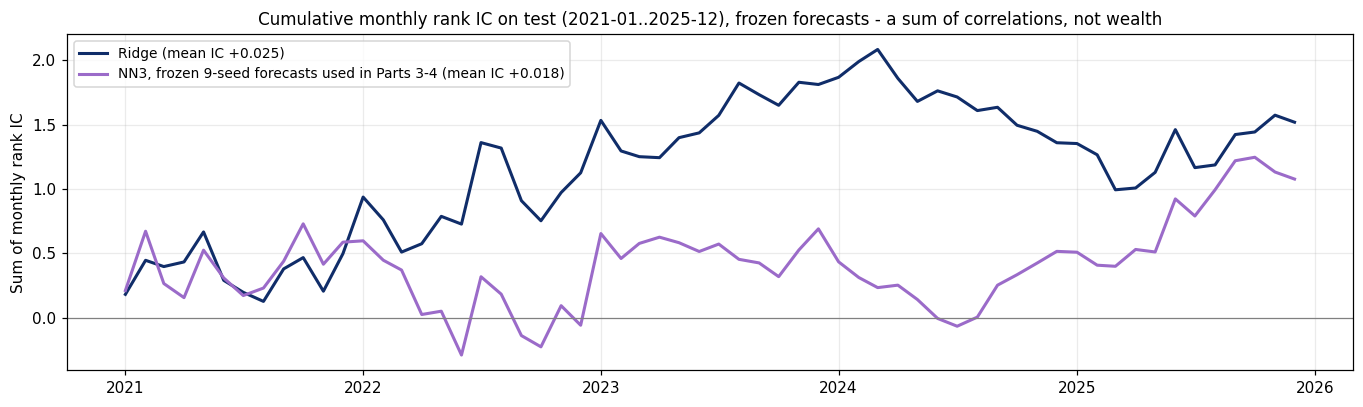

In [34]:
ic_frozen = {}
for split, df in preds.items():
    for model in ['ridge', 'nn3']:
        g = df[df.model == model]
        ic = g.groupby('holding_month')[['predicted_return', 'target_return']].apply(
            lambda x: x.predicted_return.rank().corr(x.target_return.rank()))
        ic_frozen[(split, model)] = ic
        print(f'{split:>10} {model:>5}: mean IC {ic.mean():+.4f} | t {ic.mean() / (ic.std() / np.sqrt(len(ic))):+.2f} '
              f'| months {len(ic)} | cumulative {ic.sum():+.3f}')
for split, df in preds.items():
    piv = {m: df[df.model == m].pivot(index='holding_month', columns='ticker', values='predicted_return') for m in ['ridge', 'nn3']}
    rc = np.mean([piv['ridge'].loc[h].rank().corr(piv['nn3'].loc[h].rank()) for h in piv['ridge'].index])
    print(f'{split}: mean monthly rank correlation between Ridge and NN3 forecasts = {rc:.3f}')

fig, ax = plt.subplots(figsize=(12.5, 3.8))
for model, color, label in [('ridge', NAVY, 'Ridge'), ('nn3', '#9B6BC9', 'NN3, frozen 9-seed forecasts used in Parts 3-4')]:
    ic = ic_frozen[('test', model)]
    ax.plot(pd.to_datetime(ic.index), ic.cumsum(), color=color, linewidth=2, label=f'{label} (mean IC {ic.mean():+.3f})')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('Cumulative monthly rank IC on test (2021-01..2025-12), frozen forecasts - a sum of correlations, not wealth')
ax.set_ylabel('Sum of monthly rank IC'); ax.legend(loc='upper left')
plt.tight_layout(); plt.savefig(P3_OUT / 'cumulative_ic_test_frozen.png', dpi=150); plt.show()

### Accounting

With 5 holdings the target weight is $w_{i,t} = 1/5$ and the gross return is $R^{p}_t = \sum_i w_{i,t} r_{i,t}$.

Weights drift with prices between rebalances: $\tilde w_{i,t} = w_{i,t-1}(1+r_{i,t-1}) / \sum_j w_{j,t-1}(1+r_{j,t-1})$.

Traded notional is $TO_t = \sum_i |w_{i,t} - \tilde w_{i,t}|$, between 0 and 2. This is the turnover definition used in the paper; half of it is their "one-side" turnover.

Net return with a one-way cost $c$: $1 + R^{net}_t = (1 - c\,TO_t)(1 + R^{p}_t)(1 - c\,LIQ_t)$, where the first month is bought from cash and the last portfolio is sold.

The Sharpe ratio uses a zero risk-free rate, and t-statistics of the excess return over the benchmark use Newey-West standard errors with round(T^(1/4)) = 3 lags.

### Engine

The same engine is used in Parts 3 and 4. Stock selection uses only forecasts, not actual returns. Simple tests check the portfolio calculations and benchmark.

In [35]:
N_HOLD = 5
COST_BPS = [0, 10, 25, 50]
SELECTOR_COLUMNS = ['ticker', 'predicted_return', 'rank']

def rank_month(month_df):
    """Rank 1 = highest forecast. Ties broken deterministically by ticker (A..Z)."""
    g = month_df.sort_values(['predicted_return', 'ticker'], ascending=[False, True]).reset_index(drop=True)
    g['rank'] = np.arange(1, len(g) + 1)
    return g

def select_top_k(ranked, prev_holdings, k=N_HOLD):
    """Baseline: hold the k best-ranked stocks every month."""
    return list(ranked['ticker'].iloc[:k])

def select_all(ranked, prev_holdings):
    """Benchmark: all 50 stocks, equally weighted."""
    return list(ranked['ticker'])

def run_portfolio(pred_df, selector, name):
    """Monthly long-only equal-weighted backtest with weight drift between rebalances.

    selector(ranked, prev_holdings) -> list of tickers. It only sees SELECTOR_COLUMNS,
    never target_return, so a selection rule cannot use the realised return.
    """
    w_pre = pd.Series(dtype=float)
    prev_holdings, rows = [], []
    for month, g in pred_df.groupby('holding_month', sort=True):
        ranked = rank_month(g)
        holdings = list(selector(ranked[SELECTOR_COLUMNS].copy(), list(prev_holdings)))
        assert len(holdings) == len(set(holdings)) > 0 and set(holdings) <= set(ranked.ticker), f'{name} {month}: invalid holdings'
        w_new = pd.Series(1.0 / len(holdings), index=holdings)
        universe = w_new.index.union(w_pre.index)
        dw = w_new.reindex(universe, fill_value=0.0) - w_pre.reindex(universe, fill_value=0.0)
        r = ranked.set_index('ticker')['target_return'].reindex(w_new.index)
        gross = float((w_new * r).sum())
        grown = w_new * (1.0 + r)
        w_pre = grown / grown.sum()
        rank_of = ranked.set_index('ticker')['rank']
        rows.append({'holding_month': month, 'entry_date': ranked.entry_date.iloc[0], 'exit_date': ranked.exit_date.iloc[0],
                     'n_holdings': len(holdings), 'n_new': len(set(holdings) - set(prev_holdings)),
                     'traded_notional': float(dw.abs().sum()), 'buys': float(dw.clip(lower=0).sum()),
                     'sells': float((-dw).clip(lower=0).sum()), 'gross_return': gross,
                     'mean_rank_held': float(rank_of.loc[holdings].mean()), 'holdings': ' '.join(holdings)})
        prev_holdings = holdings
    res = pd.DataFrame(rows).set_index('holding_month')
    res['liquidation_notional'] = 0.0
    res.loc[res.index[-1], 'liquidation_notional'] = float(w_pre.sum())
    res.attrs['name'] = name
    return res

def net_returns(res, cost_bps):
    """r_net = (1 - c*TO_t)(1 + r_gross)(1 - c*LIQ_t) - 1, c = one-way cost per traded dollar."""
    c = cost_bps / 10_000
    return (1 - c * res['traded_notional']) * (1 + res['gross_return']) * (1 - c * res['liquidation_notional']) - 1

def newey_west_tstat(x, lags=None):
    """t-statistic of the mean with Newey-West standard errors; default lags = round(T^(1/4))."""
    x = np.asarray(x, dtype=float)
    T = len(x)
    lags = int(round(T ** 0.25)) if lags is None else lags
    e = x - x.mean()
    s = e @ e / T
    for j in range(1, lags + 1):
        s += 2 * (1 - j / (lags + 1)) * (e[j:] @ e[:-j]) / T
    return x.mean() / np.sqrt(s / T)

def max_drawdown(r):
    wealth = np.cumprod(1 + np.asarray(r, dtype=float))
    peak = np.maximum.accumulate(np.r_[1.0, wealth])[1:]
    return float(np.max(1 - wealth / peak))

def performance(res, bench, cost_bps):
    """Metrics of one strategy at one cost level, plus its excess over the benchmark."""
    r = net_returns(res, cost_bps)
    rb = net_returns(bench, cost_bps)
    active = r - rb
    T = len(r)
    return {
        'months': T,
        'mean_gross_%': 100 * res['gross_return'].mean(),
        'mean_net_%': 100 * r.mean(),
        'ann_return_%': 100 * 12 * r.mean(),
        'CAGR_%': 100 * (np.prod(1 + r) ** (12 / T) - 1),
        'ann_vol_%': 100 * np.sqrt(12) * r.std(ddof=1),
        'Sharpe_rf0': np.sqrt(12) * r.mean() / r.std(ddof=1),
        'MDD_%': 100 * max_drawdown(r),
        'turnover': res['traded_notional'].iloc[1:].mean(),   # rebalancing months only
        'cost_drag_%': 100 * (res['gross_return'].mean() - r.mean()),
        'active_%': 100 * active.mean(),
        'active_NW_t': newey_west_tstat(active) if active.std(ddof=1) > 0 else np.nan,
        'IR': np.sqrt(12) * active.mean() / active.std(ddof=1) if active.std(ddof=1) > 0 else np.nan,
        'beat_bench_%': 100 * (active > 0).mean(),
    }
print('Engine ready: N_HOLD =', N_HOLD, '| cost scenarios (bps, one-way):', COST_BPS)

Engine ready: N_HOLD = 5 | cost scenarios (bps, one-way): [0, 10, 25, 50]


In [36]:
toy = pd.DataFrame({
    'ticker': list('ABCDEF') * 2,
    'holding_month': ['2000-01'] * 6 + ['2000-02'] * 6,
    'entry_date': pd.to_datetime(['2000-01-03'] * 6 + ['2000-02-01'] * 6),
    'exit_date': pd.to_datetime(['2000-02-01'] * 6 + ['2000-03-01'] * 6),
    'predicted_return': [6, 5, 4, 3, 2, 1,   1, 2, 3, 4, 5, 6],
    'target_return': [0.10, 0.00, 0.0, 0.0, 0.0, 0.0,   0.0, 0.0, 0.0, 0.0, 0.0, 0.0]})
t2 = run_portfolio(toy, lambda rk, prev: select_top_k(rk, prev, k=2), 'toy top-2')
assert np.isclose(t2.traded_notional.iloc[0], 1.0) and np.isclose(t2.gross_return.iloc[0], 0.05)
assert np.isclose(t2.traded_notional.iloc[1], 2.0) and np.isclose(t2.liquidation_notional.iloc[1], 1.0)
assert np.isclose(net_returns(t2, 100).iloc[0], 0.99 * 1.05 - 1)
assert np.allclose(net_returns(t2, 0), t2.gross_return)
keep = run_portfolio(toy, lambda rk, prev: ['A', 'B'], 'toy keep')
assert np.isclose(keep.traded_notional.iloc[1], abs(0.5 - 1.1 / 2.1) + abs(0.5 - 1.0 / 2.1))
seen = []
run_portfolio(toy, lambda rk, prev: seen.append(set(rk.columns)) or ['A'], 'toy guard')
assert all('target_return' not in cols for cols in seen)
x = np.array([0.01, -0.02, 0.03, 0.00, 0.015])
assert np.isclose(newey_west_tstat(x, lags=0), x.mean() / (x.std(ddof=0) / np.sqrt(len(x))))
assert np.isclose(max_drawdown([0.10, -0.20]), 0.20)
print('ALL ENGINE UNIT TESTS PASSED (8 / 8)')

ALL ENGINE UNIT TESTS PASSED (8 / 8)


In [37]:
MODELS = ['ridge', 'nn3']
MODEL_LABEL = {'ridge': 'Ridge top-5', 'nn3': 'NN3 top-5', 'bench': 'EW benchmark (50 stocks)'}
P3_RESULTS = {}
for split, df in preds.items():
    for model in MODELS:
        P3_RESULTS[(split, model)] = run_portfolio(df[df.model == model], select_top_k, f'{model} top-{N_HOLD} ({split})')
    P3_RESULTS[(split, 'bench')] = run_portfolio(df[df.model == 'ridge'], select_all, f'EW benchmark ({split})')

for split, df in preds.items():
    xs_mean = df[df.model == 'ridge'].groupby('holding_month').target_return.mean()
    assert np.allclose(P3_RESULTS[(split, 'bench')].gross_return, xs_mean)
rng = np.random.default_rng(2026)
for split, df in preds.items():
    R = df[df.model == 'ridge'].pivot(index='holding_month', columns='ticker', values='target_return').to_numpy()
    draws = np.array([[R[t, rng.choice(50, N_HOLD, replace=False)].mean() for t in range(len(R))] for _ in range(2000)])
    bench_mean = P3_RESULTS[(split, 'bench')].gross_return.mean()
    print(f'{split:>10}: random top-5 mean gross {100*draws.mean():.3f}% vs benchmark {100*bench_mean:.3f}% '
          f'(2,000 draws; 95% range of a random strategy mean: {100*np.quantile(draws.mean(1), .025):.2f}%..{100*np.quantile(draws.mean(1), .975):.2f}%)')
    P3_RESULTS[(split, 'random_band')] = np.quantile(draws.mean(1), [.025, .975])

rows = []
for (split, model), res in P3_RESULTS.items():
    if model == 'random_band':
        continue
    rows.append({'period': split, 'portfolio': MODEL_LABEL[model], 'months': len(res),
                 'first month': res.index[0], 'last month': res.index[-1],
                 'avg names changed / month': res['n_new'].iloc[1:].mean(),
                 'months with 0 changes': int((res['n_new'].iloc[1:] == 0).sum()),
                 'avg traded notional (0..2)': res['traded_notional'].iloc[1:].mean(),
                 'one-way turnover (0..1)': res['traded_notional'].iloc[1:].mean() / 2})
p3_turnover = pd.DataFrame(rows).set_index(['period', 'portfolio'])
print('\nHoldings stability and turnover (rebalancing months, i.e. excluding the initial purchase):')
print(p3_turnover.round(3).to_string())

validation: random top-5 mean gross 1.463% vs benchmark 1.474% (2,000 draws; 95% range of a random strategy mean: 0.71%..2.21%)
      test: random top-5 mean gross 1.284% vs benchmark 1.279% (2,000 draws; 95% range of a random strategy mean: 0.52%..2.03%)

Holdings stability and turnover (rebalancing months, i.e. excluding the initial purchase):
                                     months first month last month  avg names changed / month  months with 0 changes  avg traded notional (0..2)  one-way turnover (0..1)
period     portfolio                                                                                                                                                     
validation Ridge top-5                   47     2017-01    2020-11                      3.370                      0                       1.368                    0.684
           NN3 top-5                     47     2017-01    2020-11                      2.457                      1                       1.0

### Validation results

The validation period was also used by Part 2 to pick hyperparameters, so these numbers are slightly optimistic. They are the reference for the buffer choice in Part 4.

In [38]:
def performance_table(split, extra=None):
    """Metrics for the baseline portfolios and the benchmark at every cost level.
    extra: optional {label: run_portfolio result}, used by Part 4 to add the buffer portfolios."""
    rows = []
    bench = P3_RESULTS[(split, 'bench')]
    items = [(MODEL_LABEL[m], P3_RESULTS[(split, m)]) for m in MODELS + ['bench']] + list((extra or {}).items())
    for label, res in items:
        for c in COST_BPS:
            rows.append({'portfolio': label, 'cost_bps': c, **performance(res, bench, c)})
    t = pd.DataFrame(rows).set_index(['portfolio', 'cost_bps'])
    t.loc[MODEL_LABEL['bench'], ['active_%', 'active_NW_t', 'IR', 'beat_bench_%']] = np.nan
    return t

SHOW = ['mean_gross_%', 'mean_net_%', 'ann_return_%', 'ann_vol_%', 'Sharpe_rf0', 'MDD_%', 'turnover',
        'cost_drag_%', 'active_%', 'active_NW_t', 'IR', 'beat_bench_%']
perf_val = performance_table('validation')
print('Validation 2017-01..2020-11, 47 months')
print(perf_val[SHOW].round(3).to_string())

Validation 2017-01..2020-11, 47 months
                                   mean_gross_%  mean_net_%  ann_return_%  ann_vol_%  Sharpe_rf0   MDD_%  turnover  cost_drag_%  active_%  active_NW_t     IR  beat_bench_%
portfolio                cost_bps                                                                                                                                          
Ridge top-5              0                1.899       1.899        22.792     29.214       0.780  35.842     1.368       -0.000     0.426        0.660  0.320        57.447
                         10               1.899       1.758        21.099     29.164       0.723  36.077     1.368        0.141     0.294        0.456  0.221        57.447
                         25               1.899       1.547        18.560     29.091       0.638  36.428     1.368        0.353     0.095        0.148  0.072        55.319
                         50               1.899       1.194        14.328     28.973       0.495  37.

### Test results

In [39]:
perf_test = performance_table('test')
print('Test 2021-01..2025-12, 60 months')
print(perf_test[SHOW].round(3).to_string())

Test 2021-01..2025-12, 60 months
                                   mean_gross_%  mean_net_%  ann_return_%  ann_vol_%  Sharpe_rf0   MDD_%  turnover  cost_drag_%  active_%  active_NW_t     IR  beat_bench_%
portfolio                cost_bps                                                                                                                                          
Ridge top-5              0                1.523       1.523        18.272     24.142       0.757  20.349     1.284        0.000     0.243        0.494  0.188        51.667
                         10               1.523       1.391        16.697     24.127       0.692  20.581     1.284        0.131     0.121        0.246  0.093        50.000
                         25               1.523       1.195        14.335     24.107       0.595  21.374     1.284        0.328    -0.063       -0.130 -0.049        50.000
                         50               1.523       0.867        10.399     24.077       0.432  23.694   

Ridge earns 1.52% per month gross against 1.28% for the benchmark, but the difference is not significant (t = 0.49) and lies inside the range of random 5-stock portfolios. At 25 bps the advantage is already gone. The strategies are also much more volatile than the benchmark.

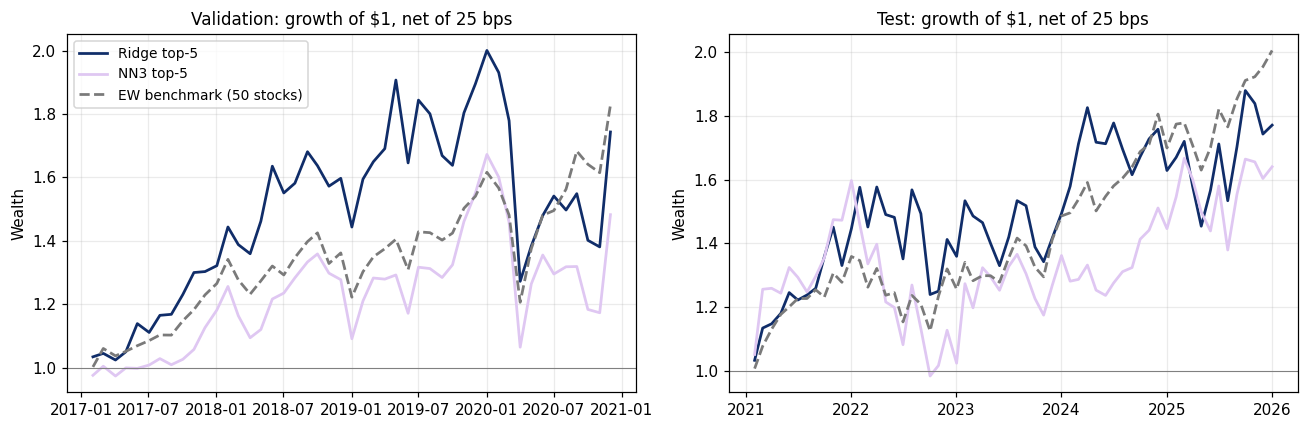

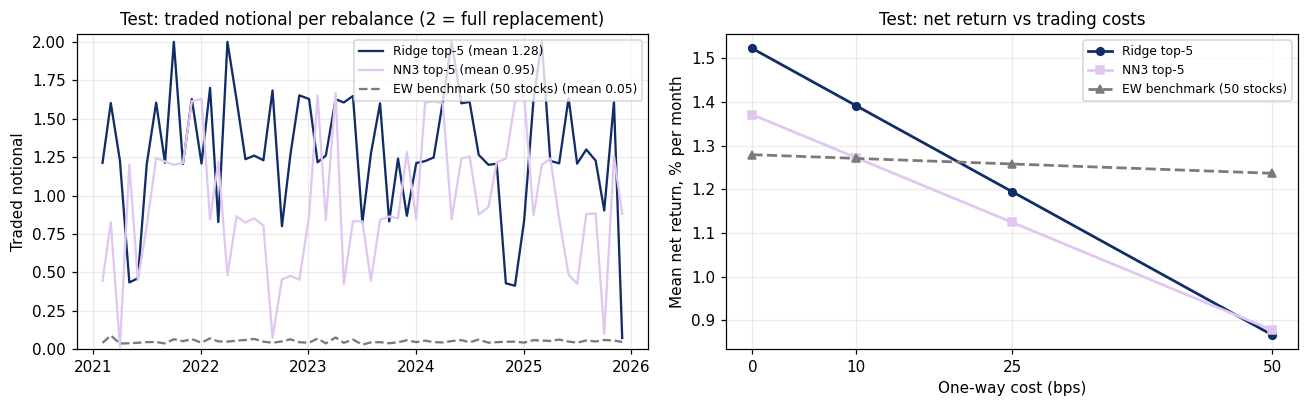

In [40]:
FIG_COST = 25
STRAT_STYLE = {'ridge': dict(color=NAVY, marker='o', linestyle='-'),
               'nn3': dict(color=LAVENDER, marker='s', linestyle='-'),
               'bench': dict(color='#7A7A7A', marker='^', linestyle='--')}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ['validation', 'test']):
    for model in MODELS + ['bench']:
        res = P3_RESULTS[(split, model)]
        w = (1 + net_returns(res, FIG_COST)).cumprod()
        style = dict(STRAT_STYLE[model]); style.pop('marker')
        ax.plot(pd.to_datetime(res.exit_date), w, label=MODEL_LABEL[model], linewidth=1.8, **style)
    ax.axhline(1, color='grey', linewidth=0.7)
    ax.set_title(f'{split.capitalize()}: growth of $1, net of {FIG_COST} bps')
    ax.set_ylabel('Wealth')
axes[0].legend(loc='upper left')
plt.tight_layout(); plt.savefig(P3_OUT / 'cumulative_wealth_25bps.png', dpi=150); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for model in MODELS + ['bench']:
    res = P3_RESULTS[('test', model)]
    style = dict(STRAT_STYLE[model]); style.pop('marker')
    axes[0].plot(pd.to_datetime(res.entry_date).iloc[1:], res.traded_notional.iloc[1:], linewidth=1.5,
                 label=f'{MODEL_LABEL[model]} (mean {res.traded_notional.iloc[1:].mean():.2f})', **style)
    axes[1].plot(COST_BPS, [perf_test.loc[(MODEL_LABEL[model], c), 'mean_net_%'] for c in COST_BPS],
                 linewidth=1.8, markersize=5, label=MODEL_LABEL[model], **STRAT_STYLE[model])
axes[0].set_ylim(0, 2.05)
axes[0].set_title('Test: traded notional per rebalance (2 = full replacement)')
axes[0].set_ylabel('Traded notional'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('One-way cost (bps)'); axes[1].set_ylabel('Mean net return, % per month')
axes[1].set_xticks(COST_BPS)
axes[1].set_title('Test: net return vs trading costs'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(P3_OUT / 'turnover_and_cost_sensitivity_test.png', dpi=150); plt.show()

### Why is turnover so high?

We measure how stable the forecast ranks are and what rank the stocks we sell still have.

In [41]:
diag = []
for split, df in preds.items():
    for model in MODELS:
        piv = df[df.model == model].pivot(index='holding_month', columns='ticker', values='predicted_return').sort_index()
        ranks = piv.rank(axis=1, ascending=False)
        persistence = pd.Series([ranks.iloc[t].corr(ranks.iloc[t - 1]) for t in range(1, len(ranks))])
        res = P3_RESULTS[(split, model)]
        exit_ranks = []
        for t in range(1, len(res)):
            prev, cur = set(res.holdings.iloc[t - 1].split()), set(res.holdings.iloc[t].split())
            exit_ranks += [ranks.iloc[t][tk] for tk in prev - cur]
        exit_ranks = np.array(exit_ranks)
        diag.append({'period': split, 'model': MODEL_LABEL[model],
                     'rank persistence (Spearman t vs t-1)': persistence.mean(),
                     'exits per month': len(exit_ranks) / (len(res) - 1),
                     'median current rank of sold stock': np.median(exit_ranks),
                     'share of sales still ranked 6-10 (%)': 100 * np.mean(exit_ranks <= 10),
                     'share of sales still ranked 6-15 (%)': 100 * np.mean(exit_ranks <= 15)})
p3_diag = pd.DataFrame(diag).set_index(['period', 'model'])
print(p3_diag.round(3).to_string())

                        rank persistence (Spearman t vs t-1)  exits per month  median current rank of sold stock  share of sales still ranked 6-10 (%)  share of sales still ranked 6-15 (%)
period     model                                                                                                                                                                            
validation Ridge top-5                                 0.354            3.370                               19.0                                24.516                                41.935
           NN3 top-5                                   0.586            2.457                               11.0                                48.673                                69.912
test       Ridge top-5                                 0.393            3.136                               14.0                                30.270                                51.351
           NN3 top-5                                   

Ranks change a lot from month to month, especially for Ridge. On test, 30% of the Ridge sales and 54% of the NN3 sales are stocks that are still ranked 6 to 10. These trades come from the strict top-5 rule, not from a real change in the forecast. This motivates the buffer in Part 4.

### Break-even cost

The cost level at which the strategy stops beating the benchmark. The paper computes a similar number as payoff divided by turnover (footnote 28) and finds 0.94% for all stocks and 0.26–0.54% without microcaps.

In [42]:
def breakeven_cost_bps(res, bench, lo=0.0, hi=2000.0):
    """One-way cost (bps) at which the strategy's mean net return equals the benchmark's (exact accounting, bisection)."""
    f = lambda c: (net_returns(res, c) - net_returns(bench, c)).mean()
    if f(lo) <= 0:
        return np.nan
    for _ in range(100):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if f(mid) > 0 else (lo, mid)
    return (lo + hi) / 2

be = []
for split in ['validation', 'test']:
    bench = P3_RESULTS[(split, 'bench')]
    for model in MODELS:
        res = P3_RESULTS[(split, model)]
        gross_active = res.gross_return.mean() - bench.gross_return.mean()
        to_all = (res.traded_notional.sum() + res.liquidation_notional.sum()) / len(res)
        to_b = (bench.traded_notional.sum() + bench.liquidation_notional.sum()) / len(bench)
        be.append({'period': split, 'portfolio': MODEL_LABEL[model],
                   'gross return minus benchmark (%/month)': 100 * gross_active,
                   'avg traded notional incl. entry & exit': to_all,
                   'linear approx. break-even (bps)': 1e4 * gross_active / (to_all - to_b),
                   'exact break-even cost (bps)': breakeven_cost_bps(res, bench)})
p3_breakeven = pd.DataFrame(be).set_index(['period', 'portfolio'])
print('Break-even one-way cost vs the equal-weighted benchmark (NaN = no gross advantage):')
print(p3_breakeven.round(3).to_string())
print('\nArticle, Section 3.4 (for scale): break-even long-short costs of 0.48%-1.12% for all stocks and '
      '0.26%-0.54% without microcaps, against estimated average costs of roughly 0.5%-0.67%.')

Break-even one-way cost vs the equal-weighted benchmark (NaN = no gross advantage):
                        gross return minus benchmark (%/month)  avg traded notional incl. entry & exit  linear approx. break-even (bps)  exact break-even cost (bps)
period     portfolio                                                                                                                                                
validation Ridge top-5                                   0.426                                   1.381                           32.845                       32.206
           NN3 top-5                                    -0.019                                   1.042                           -2.031                          NaN
test       Ridge top-5                                   0.243                                   1.296                           20.072                       19.830
           NN3 top-5                                     0.092                             

### Forecast quintiles

A diagnostic in the style of Tables 1 and 4 of the paper: sort the 50 stocks into 5 groups of 10 by forecast and compare gross returns. This long-short spread is not our strategy, which is long only.

In [43]:
qrows = []
for split, df in preds.items():
    for model in MODELS:
        d = df[df.model == model].copy()
        d['quintile'] = d.groupby('holding_month').predicted_return.rank(method='first', ascending=True).sub(1).floordiv(10).add(1).astype(int)
        q = d.groupby(['holding_month', 'quintile']).target_return.mean().unstack()
        hml = q[5] - q[1]
        row = {'period': split, 'model': MODEL_LABEL[model].replace(' top-5', '')}
        row.update({f'Q{k} (%)': 100 * q[k].mean() for k in range(1, 6)})
        row.update({'Q5-Q1 (%)': 100 * hml.mean(), 'Q5-Q1 NW t': newey_west_tstat(hml)})
        qrows.append(row)
p3_quintiles = pd.DataFrame(qrows).set_index(['period', 'model'])
print('Mean monthly gross returns of forecast quintiles (Q1 = lowest forecast, Q5 = highest):')
print(p3_quintiles.round(3).to_string())

Mean monthly gross returns of forecast quintiles (Q1 = lowest forecast, Q5 = highest):
                  Q1 (%)  Q2 (%)  Q3 (%)  Q4 (%)  Q5 (%)  Q5-Q1 (%)  Q5-Q1 NW t
period     model                                                               
validation Ridge   1.813   1.476   1.332   1.406   1.342     -0.470      -0.597
           NN3     1.312   1.720   1.508   1.651   1.177     -0.135      -0.148
test       Ridge   0.635   1.213   1.011   1.697   1.840      1.205       2.300
           NN3     0.843   0.868   1.453   1.393   1.839      0.995       1.635


The test spread is positive for Ridge (1.21%, t = 2.30), but it is negative on validation, so we do not treat it as evidence of real predictability.

### Saved results and checks

The next cells save the Part 3 tables and then recompute the main numbers with independent code: portfolio weights as NumPy matrices, a matrix form of the Newey-West variance, and the monthly returns rebuilt directly from the raw adjusted closes.

In [44]:
monthly = []
for (split, model), res in P3_RESULTS.items():
    if model == 'random_band':
        continue
    out = res.reset_index()
    out.insert(0, 'portfolio', model if model == 'bench' else f'{model}_top{N_HOLD}')
    out.insert(0, 'period', split)
    for c in COST_BPS:
        out[f'net_return_{c}bps'] = net_returns(res, c).to_numpy()
    monthly.append(out)
p3_monthly = pd.concat(monthly, ignore_index=True)
p3_monthly.to_csv(P3_OUT / 'part3_monthly_portfolio_returns.csv', index=False)
pd.concat({'validation': perf_val, 'test': perf_test}, names=['period']).to_csv(P3_OUT / 'part3_performance_summary.csv')
p3_turnover.to_csv(P3_OUT / 'part3_turnover.csv')
p3_diag.to_csv(P3_OUT / 'part3_turnover_diagnostics.csv')
p3_breakeven.to_csv(P3_OUT / 'part3_breakeven_costs.csv')
p3_quintiles.to_csv(P3_OUT / 'part3_quintile_sorts.csv')
(P3_OUT / 'part3_protocol.json').write_text(json.dumps({
    'handoff_used': str(HANDOFF.name), 'handoff_sha256': FROZEN_SHA256, 'n_hold': N_HOLD, 'cost_bps_one_way': COST_BPS,
    'weights': 'equal weights at entry_date, drift until exit_date',
    'cost_formula': 'c * sum|w_new - w_pretrade|, charged at entry; initial purchase from cash and final liquidation charged',
    'net_return': '(1 - c*TO_t)(1 + r_gross_t)(1 - c*LIQ_t) - 1',
    'tie_break': 'predicted_return descending, then ticker ascending',
    'sharpe': 'annualised, risk-free rate set to zero (approximation, no aligned T-bill series in the snapshot)',
    'benchmark': 'equal-weighted 50-stock portfolio, same schedule and same cost treatment',
    'newey_west_lags': 'round(T^(1/4)) = 3 for 47 and 60 months'}, indent=2))
print('Saved to', P3_OUT.name + ':', ', '.join(sorted(p.name for p in P3_OUT.iterdir())))

Saved to part3_portfolio: cumulative_ic_test_frozen.png, cumulative_wealth_25bps.png, part3_breakeven_costs.csv, part3_monthly_portfolio_returns.csv, part3_performance_summary.csv, part3_protocol.json, part3_quintile_sorts.csv, part3_turnover.csv, part3_turnover_diagnostics.csv, turnover_and_cost_sensitivity_test.png


In [45]:
def nw_tstat_sandwich(x, L):
    x = np.asarray(x, float); T = len(x); e = x - x.mean()
    lag = np.abs(np.subtract.outer(np.arange(T), np.arange(T)))
    K = np.where(lag <= L, 1 - lag / (L + 1), 0.0)
    return x.mean() / np.sqrt(e @ K @ e / T**2)

raw_path = ROOT / 'daily_prices.csv.gz'
adj = None
if raw_path.exists():
    daily = pd.read_csv(raw_path, usecols=['ticker', 'date', 'adj_close'], parse_dates=['date'])
    adj = daily.pivot(index='date', columns='ticker', values='adj_close')

ver, c = {}, 25 / 10_000
for split, df in preds.items():
    bench_tab = None
    for model in MODELS + ['bench']:
        d = df[df.model == ('ridge' if model == 'bench' else model)]
        P = d.pivot(index='holding_month', columns='ticker', values='predicted_return').sort_index()
        R = d.pivot(index='holding_month', columns='ticker', values='target_return').loc[P.index, P.columns].to_numpy()
        tick = P.columns.to_numpy()
        W = np.full(P.shape, 1 / 50)
        if model != 'bench':
            W = np.zeros(P.shape)
            for t in range(len(P)):
                W[t, np.lexsort((tick, -P.to_numpy()[t]))[:N_HOLD]] = 1 / N_HOLD
        gross = (W * R).sum(1)
        drift = W * (1 + R); drift /= drift.sum(1, keepdims=True)
        pre = np.vstack([np.zeros(P.shape[1]), drift[:-1]])
        TO = np.abs(W - pre).sum(1)
        net = (1 - c * TO) * (1 + gross); net[-1] *= (1 - c); net -= 1
        res = P3_RESULTS[(split, model)]
        ver[f'{split}/{model}: holdings'] = all(set(tick[W[t] > 0]) == set(res.holdings.iloc[t].split()) for t in range(len(P)))
        ver[f'{split}/{model}: gross returns'] = np.allclose(gross, res.gross_return, atol=1e-12)
        ver[f'{split}/{model}: traded notional'] = np.allclose(TO, res.traded_notional, atol=1e-12)
        ver[f'{split}/{model}: net returns at 25 bps'] = np.allclose(net, net_returns(res, 25), atol=1e-12)
        sharpe = np.sqrt(12) * net.mean() / net.std(ddof=1)
        wealth = np.cumprod(1 + net); mdd = np.max(1 - wealth / np.maximum.accumulate(np.r_[1, wealth])[1:])
        row = perf_val if split == 'validation' else perf_test
        row = row.loc[(MODEL_LABEL[model], 25)]
        ver[f'{split}/{model}: Sharpe and max drawdown at 25 bps'] = np.isclose(sharpe, row['Sharpe_rf0']) and np.isclose(100 * mdd, row['MDD_%'])
        if model == 'bench':
            continue
        if adj is not None:
            cal = d.groupby('holding_month')[['entry_date', 'exit_date']].first().loc[P.index]
            raw_gross = [np.mean(adj.loc[cal.exit_date.iloc[t], h] / adj.loc[cal.entry_date.iloc[t], h] - 1)
                         for t, h in enumerate(res.holdings.str.split())]
            ver[f'{split}/{model}: gross returns rebuilt from raw adjusted closes'] = np.allclose(raw_gross, res.gross_return, atol=1e-10)
        bnet = net_returns(P3_RESULTS[(split, 'bench')], 25).to_numpy()
        ver[f'{split}/{model}: Newey-West t (sandwich form, L=3)'] = np.isclose(nw_tstat_sandwich(net - bnet, 3), row['active_NW_t'])
        be = p3_breakeven.loc[(split, MODEL_LABEL[model]), 'exact break-even cost (bps)']
        if np.isfinite(be):
            gap = (net_returns(P3_RESULTS[(split, model)], be) - net_returns(P3_RESULTS[(split, 'bench')], be)).mean()
            ver[f'{split}/{model}: mean active return is 0 at the break-even cost'] = abs(gap) < 1e-9
if adj is not None:
    for split, df in preds.items():
        rebuilt = [adj.at[row.exit_date, row.ticker] / adj.at[row.entry_date, row.ticker] - 1 for row in df.itertuples()]
        ver[f'{split}: every target equals the entry -> exit return in the raw price file'] = np.allclose(rebuilt, df.target_return, atol=1e-9)

failed = [k for k, ok in ver.items() if not ok]
assert not failed, f'Independent verification failed: {failed}'
print(f'All {len(ver)} independent checks passed (holdings, gross returns, turnover, net returns,',
      'Sharpe, drawdown, Newey-West t, break-even cost' + (', returns rebuilt from raw prices).' if adj is not None else ').'))

All 43 independent checks passed (holdings, gross returns, turnover, net returns, Sharpe, drawdown, Newey-West t, break-even cost, returns rebuilt from raw prices).


In [46]:
P3_REFERENCE = {
    'validation|ridge|net_25bps': 1.5466751421,
    'validation|ridge|sharpe_25bps': 0.6379954458,
    'validation|ridge|turnover': 1.3678406808,
    'validation|ridge|breakeven_bps': 32.2055181452,
    'validation|nn3|net_25bps': 1.1893758791,
    'validation|nn3|sharpe_25bps': 0.4931635157,
    'validation|nn3|turnover': 1.0213322825,
    'validation|nn3|breakeven_bps': float("nan"),
    'test|ridge|net_25bps': 1.1946018905,
    'test|ridge|sharpe_25bps': 0.5946429785,
    'test|ridge|turnover': 1.2841596159,
    'test|ridge|breakeven_bps': 19.8298632252,
    'test|nn3|net_25bps': 1.1242758001,
    'test|nn3|sharpe_25bps': 0.4950958751,
    'test|nn3|turnover': 0.9524059507,
    'test|nn3|breakeven_bps': 10.1585462454,
}

p3_check_values = {}
for split, tab in [('validation', perf_val), ('test', perf_test)]:
    for model in MODELS:
        row = tab.loc[(MODEL_LABEL[model], 25)]
        p3_check_values[f'{split}|{model}|net_25bps'] = float(row['mean_net_%'])
        p3_check_values[f'{split}|{model}|sharpe_25bps'] = float(row['Sharpe_rf0'])
        p3_check_values[f'{split}|{model}|turnover'] = float(row['turnover'])
        p3_check_values[f'{split}|{model}|breakeven_bps'] = float(
            p3_breakeven.loc[(split, MODEL_LABEL[model]), 'exact break-even cost (bps)'])

worst = max(abs(p3_check_values[k] - v) for k, v in P3_REFERENCE.items() if v == v)
assert set(p3_check_values) == set(P3_REFERENCE) and worst < 1e-6, 'Part 3 results differ from the verified run'
print(f'Reproducibility check passed: {len(P3_REFERENCE)} headline numbers match the verified run '
      f'(largest difference {worst:.1e}) | pandas {pd.__version__}')

Reproducibility check passed: 16 headline numbers match the verified run (largest difference 4.6e-11) | pandas 2.2.3


### Part 3 findings

* Ridge and NN3 slightly outperform the benchmark before costs, but the differences are not statistically significant.
* Turnover is high: 64% for Ridge and 48% for NN3.
* Trading costs remove the small advantage. Ridge breaks even at around 20 bps on the test set.
* The five-stock portfolios are more volatile, while the benchmark has the highest Sharpe ratio.


### Our project and the paper

| Topic | Paper | Our project | Our result |
|---|---|---|---|
| Universe | all U.S. stocks, subsamples without microcaps, non-rated and distressed firms (Section 2.2) | 50 large surviving stocks | close to their "cheap-to-trade" subsamples |
| Portfolio | value-weighted top-minus-bottom decile (Section 3) | equal-weighted long-only top 5 of 50 | — |
| Payoff | GKX 1.56% per month, FF6 alpha 0.92%; 0.31% and insignificant without microcaps (Table 1) | excess return over the equal-weighted benchmark | +0.24% on test, t = 0.49 |
| Turnover | 0.976 for the GKX long-short portfolio = one-side long + one-side short (Table 5, p. 2601); one-side turnover at least 43% | one long book: traded notional Σ|Δw| (0–2) = 2 × one-side turnover | traded notional 1.28 (Ridge), 0.95 (NN3); one-side 64% and 48% — compare with the paper only in one-side terms |
| Break-even cost | 0.94% all stocks, 0.26–0.54% without microcaps (Section 3.4) | cost where the strategy stops beating the benchmark | 20 bps (Ridge), 10 bps (NN3) |
| Inference | Newey-West, 4 lags (footnote 19) | Newey-West, 3 lags | all excess returns insignificant |

We do not reproduce the numbers of the paper. We repeat its turnover and cost logic on a much smaller and easier universe, with raw benchmark-adjusted returns instead of factor alphas.

## 4. Buffer strategy

We test a buffer strategy to reduce unnecessary trading. Stocks already in the portfolio are kept while their rank is within the buffer. The remaining places are filled with the highest-ranked stocks, keeping the portfolio at five stocks.

We test buffer thresholds of 8, 10 and 15. For each model, we choose the threshold with the highest net Sharpe ratio on validation at 25 bps and keep it fixed for the test period. We use block bootstrap to check whether the improvement is statistically significant.


In [47]:
import datetime
from functools import partial

P4_OUT = ROOT / 'part4_buffer'
P4_OUT.mkdir(parents=True, exist_ok=True)

P4_BUFFERS = [8, 10, 15]
P4_SELECTION_COST = 25
P4_BLOCK_LENGTH = 6
P4_BOOTSTRAP_SAMPLES = 10_000
P4_BOOTSTRAP_SEED = 17

p4_protocol = {
    'candidate_exit_ranks': P4_BUFFERS,
    'portfolio_size': N_HOLD,
    'selection': 'separate threshold for Ridge and NN3',
    'primary_criterion': f'highest validation net Sharpe_rf0 at {P4_SELECTION_COST} bps',
    'tie_break': 'smaller exit rank',
    'buffer_rule': 'retain previous holdings with rank <= B; fill empty slots with the best-ranked non-retained stocks',
    'bootstrap': {'type': 'circular block bootstrap', 'block_length_months': P4_BLOCK_LENGTH,
                  'n_resamples': P4_BOOTSTRAP_SAMPLES, 'seed': P4_BOOTSTRAP_SEED},
    'test_rule': 'choose on validation only; freeze before test evaluation',
    'selected_exit_rank': {'ridge': None, 'nn3': None},
}
(P4_OUT / 'frozen_buffer.json').write_text(json.dumps(p4_protocol, indent=2))
print(json.dumps(p4_protocol, indent=2))

{
  "candidate_exit_ranks": [
    8,
    10,
    15
  ],
  "portfolio_size": 5,
  "selection": "separate threshold for Ridge and NN3",
  "primary_criterion": "highest validation net Sharpe_rf0 at 25 bps",
  "tie_break": "smaller exit rank",
  "buffer_rule": "retain previous holdings with rank <= B; fill empty slots with the best-ranked non-retained stocks",
  "bootstrap": {
    "type": "circular block bootstrap",
    "block_length_months": 6,
    "n_resamples": 10000,
    "seed": 17
  },
  "test_rule": "choose on validation only; freeze before test evaluation",
  "selected_exit_rank": {
    "ridge": null,
    "nn3": null
  }
}


### Buffer rule and tests

The last test checks that B = 5 gives exactly the Part 3 baseline, which confirms that the two strategies differ only in the selection rule.

In [48]:
def p4_select_buffer(ranked, prev_holdings, exit_rank):
    """Keep old holdings while their rank <= exit_rank, then fill up to N_HOLD with the best new stocks."""
    rank_map = ranked.set_index('ticker')['rank'].to_dict()
    retained = [t for t in prev_holdings if t in rank_map and rank_map[t] <= exit_rank]
    new_stocks = [t for t in ranked['ticker'] if t not in retained][:N_HOLD - len(retained)]
    holdings = retained + new_stocks
    assert len(holdings) == len(set(holdings)) == N_HOLD
    return holdings

p4_prev = ['A', 'B', 'C', 'D', 'E']
ranked_1 = pd.DataFrame({'ticker': ['A', 'B', 'C', 'D', 'F', 'E', 'G', 'H', 'I', 'J'], 'rank': range(1, 11)})
ranked_2 = pd.DataFrame({'ticker': ['A', 'B', 'C', 'D', 'F', 'G', 'H', 'I', 'E', 'J'], 'rank': range(1, 11)})

assert p4_select_buffer(ranked_1, p4_prev, exit_rank=8) == ['A', 'B', 'C', 'D', 'E']
assert p4_select_buffer(ranked_2, p4_prev, exit_rank=8) == ['A', 'B', 'C', 'D', 'F']
assert p4_select_buffer(ranked_1, [], exit_rank=8) == ['A', 'B', 'C', 'D', 'F']
for model in MODELS:
    check = run_portfolio(preds['validation'][preds['validation'].model == model],
                          partial(p4_select_buffer, exit_rank=N_HOLD), f'{model} buffer B=5')
    assert np.allclose(check.gross_return, P3_RESULTS[('validation', model)].gross_return)

print('Buffer rule tests passed: E is kept at rank 6 with B=8, dropped when its rank is 9,')
print('the first month starts from the top 5, and B=5 reproduces the Part 3 baseline exactly.')

Buffer rule tests passed: E is kept at rank 6 with B=8, dropped when its rank is 9,
the first month starts from the top 5, and B=5 reproduces the Part 3 baseline exactly.


### Validation: all candidates

In [49]:
p4_val, val_rows = {}, []
for model in MODELS:
    for B in P4_BUFFERS:
        res = run_portfolio(preds['validation'][preds['validation'].model == model],
                            partial(p4_select_buffer, exit_rank=B), f'{model}_buffer_{B}')
        p4_val[(model, B)] = res
        for cost in COST_BPS:
            perf = performance(res, P3_RESULTS[('validation', 'bench')], cost)
            val_rows.append({'model': model, 'B': B, 'cost_bps': cost,
                             'mean_gross_%': perf['mean_gross_%'], 'mean_net_%': perf['mean_net_%'],
                             'ann_vol_%': perf['ann_vol_%'], 'Sharpe_rf0': perf['Sharpe_rf0'],
                             'MDD_%': perf['MDD_%'], 'turnover': perf['turnover']})

p4_validation_table = pd.DataFrame(val_rows)
p4_validation_table.to_csv(P4_OUT / 'P4_validation_candidates.csv', index=False)
print(p4_validation_table.round(3).to_string(index=False))

model  B  cost_bps  mean_gross_%  mean_net_%  ann_vol_%  Sharpe_rf0  MDD_%  turnover
ridge  8         0         1.877       1.877     28.927       0.779 36.052     1.097
ridge  8        10         1.877       1.763     28.868       0.733 36.261     1.097
ridge  8        25         1.877       1.591     28.783       0.663 36.573     1.097
ridge  8        50         1.877       1.305     28.646       0.547 37.092     1.097
ridge 10         0         2.012       2.012     29.544       0.817 36.052     1.019
ridge 10        10         2.012       1.905     29.476       0.775 36.236     1.019
ridge 10        25         2.012       1.744     29.374       0.712 36.511     1.019
ridge 10        50         2.012       1.477     29.210       0.607 36.967     1.019
ridge 15         0         1.648       1.648     29.505       0.670 34.393     0.782
ridge 15        10         1.648       1.566     29.468       0.638 34.554     0.782
ridge 15        25         1.648       1.442     29.413       0.5

### Selection and freezing

In [50]:
selection_table = p4_validation_table[p4_validation_table['cost_bps'] == P4_SELECTION_COST].copy()
p4_selected = {}
for model in MODELS:
    best = selection_table[selection_table['model'] == model].sort_values(['Sharpe_rf0', 'B'], ascending=[False, True])
    p4_selected[model] = int(best.iloc[0]['B'])

p4_protocol['selected_exit_rank'] = p4_selected
p4_protocol['frozen_at_utc'] = datetime.datetime.now(datetime.timezone.utc).isoformat(timespec='seconds')
(P4_OUT / 'frozen_buffer.json').write_text(json.dumps(p4_protocol, indent=2))
selection_table.to_csv(P4_OUT / 'validation_buffer_selection.csv', index=False)

print('Selected on validation and frozen before the test:', p4_selected)
print(selection_table[['model', 'B', 'mean_net_%', 'Sharpe_rf0', 'turnover']].round(3).to_string(index=False))

Selected on validation and frozen before the test: {'ridge': 10, 'nn3': 8}
model  B  mean_net_%  Sharpe_rf0  turnover
ridge  8       1.591       0.663     1.097
ridge 10       1.744       0.712     1.019
ridge 15       1.442       0.588     0.782
  nn3  8       1.210       0.504     0.662
  nn3 10       0.970       0.389     0.496
  nn3 15       1.208       0.499     0.362


### Test results with the frozen buffer

In [53]:
p4_test, p4_final_rows = {}, []
for model in MODELS:
    B = p4_selected[model]
    p4_test[model] = run_portfolio(preds['test'][preds['test'].model == model],
                                   partial(p4_select_buffer, exit_rank=B), f'{model}_buffer_{B}')
    strategies = {'Baseline': P3_RESULTS[('test', model)], f'Buffer B={B}': p4_test[model],
                  'Equal-weight benchmark': P3_RESULTS[('test', 'bench')]}
    for strategy, res in strategies.items():
        for cost in COST_BPS:
            perf = performance(res, P3_RESULTS[('test', 'bench')], cost)
            p4_final_rows.append({'model': model, 'strategy': strategy, 'cost_bps': cost,
                                  'mean_gross_%': perf['mean_gross_%'], 'mean_net_%': perf['mean_net_%'],
                                  'ann_vol_%': perf['ann_vol_%'], 'Sharpe_rf0': perf['Sharpe_rf0'],
                                  'MDD_%': perf['MDD_%'], 'turnover': perf['turnover']})

p4_final_table = pd.DataFrame(p4_final_rows)
p4_final_table.to_csv(P4_OUT / 'P4_test_performance.csv', index=False)
print(p4_final_table.round(3).to_string(index=False))

model               strategy  cost_bps  mean_gross_%  mean_net_%  ann_vol_%  Sharpe_rf0  MDD_%  turnover
ridge               Baseline         0         1.523       1.523     24.142       0.757 20.349     1.284
ridge               Baseline        10         1.523       1.391     24.127       0.692 20.581     1.284
ridge               Baseline        25         1.523       1.195     24.107       0.595 21.374     1.284
ridge               Baseline        50         1.523       0.867     24.077       0.432 23.694     1.284
ridge            Buffer B=10         0         1.884       1.884     25.276       0.895 16.545     0.924
ridge            Buffer B=10        10         1.884       1.789     25.287       0.849 16.690     0.924
ridge            Buffer B=10        25         1.884       1.646     25.306       0.781 16.906     0.924
ridge            Buffer B=10        50         1.884       1.408     25.342       0.667 17.913     0.924
ridge Equal-weight benchmark         0         1.279   

In [54]:
def p4_block_bootstrap(diff, block_length=P4_BLOCK_LENGTH, n_samples=P4_BOOTSTRAP_SAMPLES, seed=P4_BOOTSTRAP_SEED):
    """Circular block bootstrap of the mean paired difference; blocks keep the monthly dependence."""
    x = np.asarray(diff, dtype=float)
    n = len(x)
    rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(n / block_length))
    starts = rng.integers(0, n, size=(n_samples, n_blocks))
    idx = (starts[:, :, None] + np.arange(block_length)) % n
    boot_means = x[idx.reshape(n_samples, -1)[:, :n]].mean(axis=1)
    return {'mean_diff': x.mean(), 'ci_low': np.percentile(boot_means, 2.5),
            'ci_high': np.percentile(boot_means, 97.5), 'share_le_zero': np.mean(boot_means <= 0)}

p4_paired_rows = []
for model in MODELS:
    for cost in COST_BPS:
        diff = net_returns(p4_test[model], cost) - net_returns(P3_RESULTS[('test', model)], cost)
        boot = p4_block_bootstrap(diff)
        buffer_perf = performance(p4_test[model], P3_RESULTS[('test', 'bench')], cost)
        baseline_perf = performance(P3_RESULTS[('test', model)], P3_RESULTS[('test', 'bench')], cost)
        p4_paired_rows.append({'model': model, 'cost_bps': cost,
                               'mean_net_diff_%': 100 * boot['mean_diff'],
                               'CI_low_%': 100 * boot['ci_low'], 'CI_high_%': 100 * boot['ci_high'],
                               'share_bootstrap_le_zero': boot['share_le_zero'],
                               'Sharpe_buffer': buffer_perf['Sharpe_rf0'],
                               'Sharpe_baseline': baseline_perf['Sharpe_rf0'],
                               'Sharpe_diff': buffer_perf['Sharpe_rf0'] - baseline_perf['Sharpe_rf0']})

p4_paired = pd.DataFrame(p4_paired_rows)
p4_paired.to_csv(P4_OUT / 'P4_paired_bootstrap.csv', index=False)
print(p4_paired.round(4).to_string(index=False))

model  cost_bps  mean_net_diff_%  CI_low_%  CI_high_%  share_bootstrap_le_zero  Sharpe_buffer  Sharpe_baseline  Sharpe_diff
ridge         0           0.3616   -0.1735     0.9619                   0.1003         0.8946           0.7569       0.1377
ridge        10           0.3976   -0.1359     0.9997                   0.0778         0.8490           0.6920       0.1569
ridge        25           0.4516   -0.0787     1.0551                   0.0511         0.7806           0.5946       0.1860
ridge        50           0.5415    0.0155     1.1522                   0.0224         0.6668           0.4319       0.2349
  nn3         0           0.4545   -0.1347     1.1366                   0.0762         0.7876           0.6017       0.1858
  nn3        10           0.4847   -0.1036     1.1646                   0.0620         0.7589           0.5592       0.1998
  nn3        25           0.5299   -0.0549     1.2078                   0.0427         0.7158           0.4951       0.2207
  nn3   

In [55]:
p4_turnover_rows = []
for model in MODELS:
    baseline, buffer = P3_RESULTS[('test', model)], p4_test[model]
    baseline_turnover = baseline['traded_notional'].iloc[1:].mean()
    buffer_turnover = buffer['traded_notional'].iloc[1:].mean()
    p4_turnover_rows.append({
        'model': model, 'B': p4_selected[model],
        'baseline_turnover': baseline_turnover, 'buffer_turnover': buffer_turnover,
        'turnover_change_%': 100 * (buffer_turnover / baseline_turnover - 1),
        'baseline_new_names': baseline['n_new'].iloc[1:].mean(),
        'buffer_new_names': buffer['n_new'].iloc[1:].mean(),
        'baseline_total_notional': baseline['traded_notional'].sum() + baseline['liquidation_notional'].sum(),
        'buffer_total_notional': buffer['traded_notional'].sum() + buffer['liquidation_notional'].sum()})

p4_turnover = pd.DataFrame(p4_turnover_rows)
p4_turnover.to_csv(P4_OUT / 'P4_turnover_comparison.csv', index=False)
print(p4_turnover.round(3).to_string(index=False))

model  B  baseline_turnover  buffer_turnover  turnover_change_%  baseline_new_names  buffer_new_names  baseline_total_notional  buffer_total_notional
ridge 10              1.284            0.924            -28.063               3.136             2.203                   77.765                 56.503
  nn3  8              0.952            0.646            -32.217               2.271             1.492                   58.192                 40.088


### H1: does the buffer reduce trading?

Yes. On test the buffer cuts average rebalancing turnover from 1.28 to 0.92 for Ridge (−28%) and from 0.95 to 0.65 for NN3 (−32%), while the portfolio still holds five stocks. The number of new names per month falls from 3.1 to 2.2 and from 2.3 to 1.5.

### H2: does it improve net performance?

At 25 bps the buffer earns 0.45 pp (Ridge) and 0.53 pp (NN3) more per month than the baseline, and the net Sharpe ratio rises from 0.59 to 0.78 and from 0.50 to 0.72. The 95% bootstrap intervals still contain zero, so the improvement is not statistically clear.

Two points are important for the interpretation. First, the gain is not only a cost effect: at 0 bps the buffer is already 0.36 pp (Ridge) and 0.45 pp (NN3) ahead, so most of the difference comes from holding different stocks, and only a smaller part from lower costs. Second, the buffer beats its own baseline but not the benchmark on a risk-adjusted basis: the equal-weighted portfolio still has the highest Sharpe ratio.

### Figures

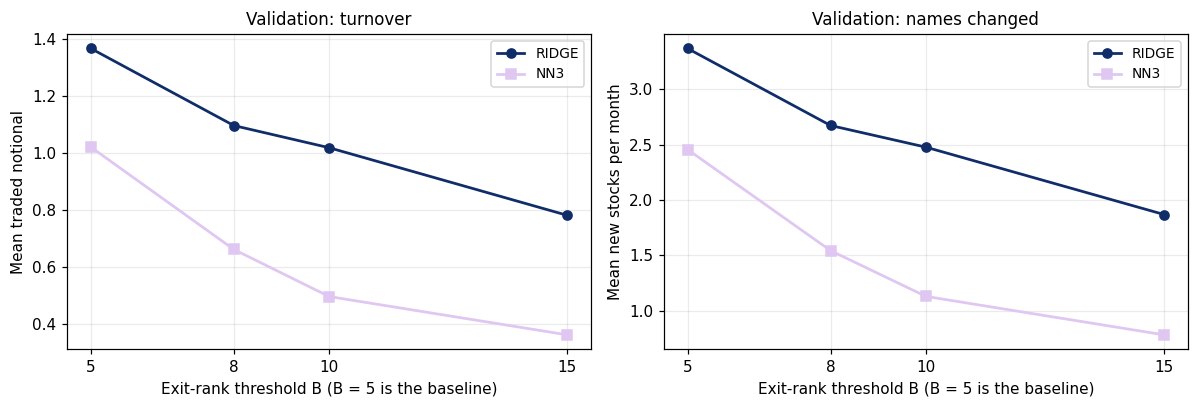

In [56]:
p4_plot_rows = []
for model in MODELS:
    base = P3_RESULTS[('validation', model)]
    p4_plot_rows.append({'model': model, 'B': N_HOLD, 'turnover': base['traded_notional'].iloc[1:].mean(),
                         'n_new': base['n_new'].iloc[1:].mean()})
    for B in P4_BUFFERS:
        res = p4_val[(model, B)]
        p4_plot_rows.append({'model': model, 'B': B, 'turnover': res['traded_notional'].iloc[1:].mean(),
                             'n_new': res['n_new'].iloc[1:].mean()})
p4_plot = pd.DataFrame(p4_plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for model in MODELS:
    d = p4_plot[p4_plot['model'] == model]
    style = dict(STRAT_STYLE[model]); style['linestyle'] = '-'
    axes[0].plot(d['B'], d['turnover'], linewidth=1.8, markersize=6, label=model.upper(), **style)
    axes[1].plot(d['B'], d['n_new'], linewidth=1.8, markersize=6, label=model.upper(), **style)
for ax, ylab, title in [(axes[0], 'Mean traded notional', 'Validation: turnover'),
                        (axes[1], 'Mean new stocks per month', 'Validation: names changed')]:
    ax.set_xlabel('Exit-rank threshold B (B = 5 is the baseline)')
    ax.set_ylabel(ylab); ax.set_title(title); ax.set_xticks([5, 8, 10, 15]); ax.legend()
plt.tight_layout(); plt.savefig(P4_OUT / 'P4_validation_turnover.png', dpi=150); plt.show()

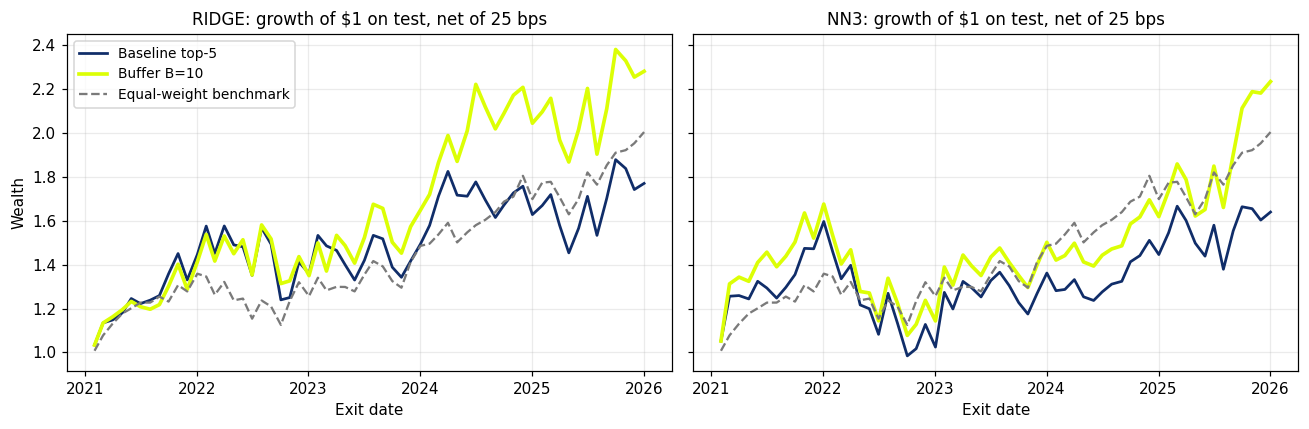

In [57]:
P4_COST = 25
bench_net = net_returns(P3_RESULTS[('test', 'bench')], P4_COST)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, model in zip(axes, MODELS):
    dates = pd.to_datetime(P3_RESULTS[('test', model)].exit_date)
    ax.plot(dates, (1 + net_returns(P3_RESULTS[('test', model)], P4_COST)).cumprod(),
            color=NAVY, linewidth=1.8, label='Baseline top-5')
    ax.plot(dates, (1 + net_returns(p4_test[model], P4_COST)).cumprod(),
            color=LIME, linewidth=2.4, label=f'Buffer B={p4_selected[model]}')
    ax.plot(dates, (1 + bench_net).cumprod(), color='#7A7A7A', linestyle='--', linewidth=1.5,
            label='Equal-weight benchmark')
    ax.set_title(f'{model.upper()}: growth of $1 on test, net of {P4_COST} bps')
    ax.set_xlabel('Exit date')
axes[0].set_ylabel('Wealth'); axes[0].legend(loc='upper left')
plt.tight_layout(); plt.savefig(P4_OUT / 'P4_test_wealth.png', dpi=150); plt.show()

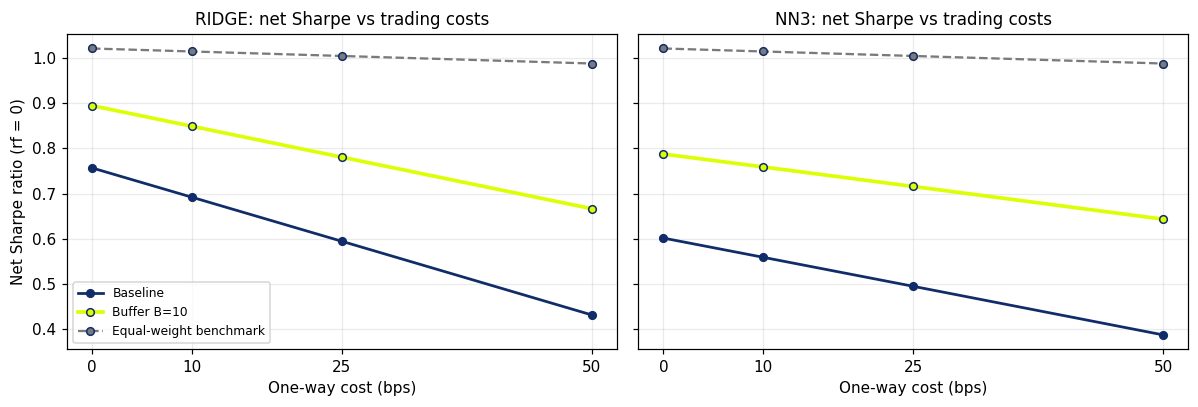

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    d = p4_final_table[p4_final_table['model'] == model]
    for strategy, color, lw in [('Baseline', NAVY, 1.8), (f'Buffer B={p4_selected[model]}', LIME, 2.4),
                                ('Equal-weight benchmark', '#7A7A7A', 1.5)]:
        s = d[d['strategy'] == strategy]
        ax.plot(s['cost_bps'], s['Sharpe_rf0'], marker='o', markersize=5, color=color, linewidth=lw,
                markeredgecolor=NAVY, linestyle='--' if 'benchmark' in strategy else '-', label=strategy)
    ax.set_title(f'{model.upper()}: net Sharpe vs trading costs')
    ax.set_xlabel('One-way cost (bps)'); ax.set_xticks(COST_BPS)
axes[0].set_ylabel('Net Sharpe ratio (rf = 0)'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(P4_OUT / 'P4_cost_sensitivity.png', dpi=150); plt.show()

### Main result at 25 bps

In [59]:
p4_summary_rows = []
for model in MODELS:
    B = p4_selected[model]
    for strategy, res in [('Baseline top-5', P3_RESULTS[('test', model)]), (f'Buffer B={B}', p4_test[model]),
                          ('Equal-weight benchmark', P3_RESULTS[('test', 'bench')])]:
        perf = performance(res, P3_RESULTS[('test', 'bench')], P4_SELECTION_COST)
        p4_summary_rows.append({'model': model.upper(), 'strategy': strategy,
                                'mean_gross_%': perf['mean_gross_%'], 'mean_net_%': perf['mean_net_%'],
                                'Sharpe': perf['Sharpe_rf0'], 'MDD_%': perf['MDD_%'], 'turnover': perf['turnover']})

p4_summary = pd.DataFrame(p4_summary_rows)
p4_summary.to_csv(P4_OUT / 'P4_main_results_25bps.csv', index=False)
print(f'Test period, net of {P4_SELECTION_COST} bps')
print(p4_summary.round(3).to_string(index=False))

Test period, net of 25 bps
model               strategy  mean_gross_%  mean_net_%  Sharpe  MDD_%  turnover
RIDGE         Baseline top-5         1.523       1.195   0.595 21.374     1.284
RIDGE            Buffer B=10         1.884       1.646   0.781 16.906     0.924
RIDGE Equal-weight benchmark         1.279       1.258   1.004 17.173     0.051
  NN3         Baseline top-5         1.371       1.124   0.495 38.372     0.952
  NN3             Buffer B=8         1.825       1.654   0.716 35.725     0.646
  NN3 Equal-weight benchmark         1.279       1.258   1.004 17.173     0.051


### Decomposition of the buffer gain

The gain at 0 bps cannot come from saving trading costs, so it measures the effect of holding different stocks. The extra gain at 25 bps is the cost saving. The comparison with the equal-weighted benchmark uses the same Newey–West (3 lags) test as Part 3.


In [60]:

bench_res = P3_RESULTS[('test', 'bench')]
rows = []
for model in MODELS:
    base, buf = P3_RESULTS[('test', model)], p4_test[model]
    gain0 = (net_returns(buf, 0) - net_returns(base, 0)).mean() * 100
    gain25 = (net_returns(buf, 25) - net_returns(base, 25)).mean() * 100
    val_gross = (net_returns(p4_val[(model, p4_selected[model])], 0) - net_returns(P3_RESULTS[('validation', model)], 0)).mean() * 100
    ex = net_returns(buf, 25) - net_returns(bench_res, 25)
    rows.append({'model': model, 'B': p4_selected[model], 'gain_0bps_pp': gain0, 'gain_25bps_pp': gain25,
                 'share_of_25bps_gain_already_at_0bps_%': 100 * gain0 / gain25,
                 'validation_gross_gain_pp': val_gross,
                 'buffer_minus_EW_25bps_pp': ex.mean() * 100, 'buffer_minus_EW_NW_t': nw_tstat_sandwich(ex.to_numpy(), 3)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

model  B  gain_0bps_pp  gain_25bps_pp  share_of_25bps_gain_already_at_0bps_%  validation_gross_gain_pp  buffer_minus_EW_25bps_pp  buffer_minus_EW_NW_t
ridge 10         0.362          0.452                                 80.082                     0.112                     0.388                 0.835
  nn3  8         0.454          0.530                                 85.761                    -0.069                     0.396                 0.665


## 5. Conclusion

Our portfolios show a small advantage before costs, but it is not statistically significant. High turnover and trading costs remove this advantage. The buffer reduces turnover and improves returns in our sample, but the improvement is not statistically significant, and the benchmark has the highest Sharpe ratio. Our results support the paper’s focus on trading costs, but our smaller dataset limits the conclusions.

### Limitations

- 50 large surviving U.S. stocks, chosen afterwards, so the sample has survivorship bias and is not the universe of the paper.
- Trading costs are fixed scenarios, not measured spreads or market impact; the Sharpe ratio uses a zero risk-free rate.
- 47 validation and 60 test months give little statistical power, so most differences are not significant.
- The strategies are long only with five stocks, while the paper studies value-weighted long-short deciles and risk-adjusted returns.
- The 50 tickers were fixed in 2026 among companies that exist today, so the test is out-of-sample for the models and the buffer, but not for the choice of stocks.
- NN3 is not reproducible across runs: two runs of the same code gave test IC +0.018 (frozen, used in Parts 3–4) and −0.011 (re-run printed in Part 2). See the correction note after cell 32.
- Most of the buffer gain comes from holding different stocks (it exists at 0 bps) and did not appear on validation; the gain is not statistically significant and the buffer does not beat the benchmark in Sharpe ratio.
